In [707]:
import pandas as pd
import os
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

pd.set_option('display.notebook_repr_html', True)

def create_seaborn_boxplot(data, x, y, ax, title, ylabel, xlabel, custom_means=None):
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
    unique_vals = sorted(data[x].unique())
    palette = colors[:len(unique_vals)]
    
    sns.boxplot(data=data, x=x, y=y, ax=ax, palette=palette,
                medianprops={'color': 'black', 'linewidth': 2.5, 'linestyle': ':'})
    
    plot_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    
    if custom_means is not None:
        # Use custom means if provided, mapping them to the correct plot positions
        for i, plot_label in enumerate(plot_labels):
            reverse_mapping = {
                'Anthropic': 'anthropic',
                'OpenAI': 'openai', 
                'Google': 'google',
                'DeepSeek': 'deepseek',
                'Common': 'common',
                'Complex': 'complex',
                'Script': 'script',
                'Transcript': 'transcript', 
                'Tanenbaum': 'tanenbaum',
                'Script (Manipulated)': 'script_manipulated',
                'No Source': 'no_source',
                'Exp 1a': '1a',
                'Exp 1b': '1b'
            }
            original_category = reverse_mapping.get(plot_label, plot_label.lower())
            
            if original_category in custom_means.index:
                mean_val = custom_means[original_category]
                ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, 
                          edgecolor='darkred', linewidth=1)
    else:
        # Use original behavior if no custom means provided
        for i, val in enumerate(unique_vals):
            mean_val = data[data[x] == val][y].mean()
            ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, 
                      edgecolor='darkred', linewidth=1)
    
    label_mapping = {
        'anthropic': 'Anthropic',
        'openai': 'OpenAI', 
        'google': 'Google',
        'deepseek': 'DeepSeek',
        'common': 'Common',
        'complex': 'Complex',
        'script': 'Script',
        'transcript': 'Transcript', 
        'tanenbaum': 'Tanenbaum',
        'script_manipulated': 'Script (Manipulated)',
        'no_source': 'No Source',
        '1a': 'Exp 1a',
        '1b': 'Exp 1b'
    }
    
    current_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    new_labels = [label_mapping.get(label, label) for label in current_labels]
    ax.set_xticklabels(new_labels, rotation=0)
    
    if 'cosine_similarity' in y.lower():
        ylabel = 'Cosine Similarity'
        if '(-1 to 1)' not in title:
            title = title.replace('Cosine Similarity', 'Cosine Similarity (-1 to 1)')
    elif 'adherence_score' in y.lower():
        ylabel = 'Adherence Score'
        if '(0 to 1)' not in title:
            title = title.replace('Adherence Score', 'Adherence Score (0 to 1)')
    
    if x.lower() == 'llm':
        xlabel = 'LLM'
    elif x.lower() == 'prompt_type':
        xlabel = 'Prompt Type'
    elif x.lower() == 'input_source':
        xlabel = 'Input Source'
    elif x.lower() == 'comparison_source':
        xlabel = 'Comparison Source'
    elif x.lower() == 'layer':
        xlabel = 'Layer'
    elif x.lower() == 'experiment':
        xlabel = 'Experiment'
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, labelpad=15)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10)
    ax.grid(True, alpha=0.3)

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
INPUT_PATH = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/quantitative")
OUTPUT_PATH = os.path.join(BASE_PROJECT_PATH, "40_evaluation/exp1/quantitative/")

exp1a_path = os.path.join(INPUT_PATH, "exp1a.csv")
exp1b_path = os.path.join(INPUT_PATH, "exp1b.csv")
exp1a_no_source_path = os.path.join(INPUT_PATH, "exp1a_no_source.csv")

output_dir_exp1a = os.path.join(OUTPUT_PATH, "tables/exp1a")
output_dir_exp1b = os.path.join(OUTPUT_PATH, "tables/exp1b")
output_plot_dir_exp1a = os.path.join(OUTPUT_PATH, "plots/exp1a")
output_plot_dir_exp1b = os.path.join(OUTPUT_PATH, "plots/exp1b")

tables = {}
plots = {}

for path in [output_dir_exp1a, output_dir_exp1b, output_plot_dir_exp1a, output_plot_dir_exp1b]:
    os.makedirs(path, exist_ok=True)

if not os.path.exists(exp1a_path) or not os.path.exists(exp1b_path):
    print("Error: Quantitative data files not found.")
    print(f"Looked for {exp1a_path} and {exp1b_path}")
else:
    exp1a_df = pd.read_csv(exp1a_path)
    exp1b_df = pd.read_csv(exp1b_path)
    
    # Load exp1a_no_source if available
    exp1a_no_source_df = None
    if os.path.exists(exp1a_no_source_path):
        exp1a_no_source_df = pd.read_csv(exp1a_no_source_path)
        if 'comparison_source' in exp1a_no_source_df.columns:
            # For expanded CSV structure
            exp1a_no_source_df["adherence_score"] = exp1a_no_source_df[
                ["adherence_score_openai", "adherence_score_anthropic"]
            ].mean(axis=1)
            exp1a_no_source_df = exp1a_no_source_df.drop(
                columns=["adherence_score_openai", "adherence_score_anthropic"]
            )
        else:
            # For legacy CSV structure
            exp1a_no_source_df["adherence_score"] = exp1a_no_source_df[
                ["adherence_score_openai", "adherence_score_anthropic"]
            ].mean(axis=1)
            exp1a_no_source_df = exp1a_no_source_df.drop(
                columns=["adherence_score_openai", "adherence_score_anthropic"]
            )
        
        print("Data loaded and preprocessed for exp1a, exp1b, and exp1a_no_source.")
    else:
        print("Warning: exp1a_no_source data not found. Some plots may be skipped.")
        print("Data loaded and preprocessed for exp1a and exp1b only.")

    exp1a_df["adherence_score"] = exp1a_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)
    exp1b_df["adherence_score"] = exp1b_df[
        ["adherence_score_openai", "adherence_score_anthropic"]
    ].mean(axis=1)

    exp1a_df = exp1a_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )
    exp1b_df = exp1b_df.drop(
        columns=["adherence_score_openai", "adherence_score_anthropic"]
    )

Data loaded and preprocessed for exp1a, exp1b, and exp1a_no_source.


In [708]:
exp1a_no_source_path = os.path.join(INPUT_PATH, "exp1a_no_source.csv")
output_dir_exp1a_no_source = os.path.join(OUTPUT_PATH, "tables/exp1a_no_source")
output_plot_dir_exp1a_no_source = os.path.join(OUTPUT_PATH, "plots/exp1a_no_source")

for path in [output_dir_exp1a_no_source, output_plot_dir_exp1a_no_source]:
    os.makedirs(path, exist_ok=True)

## Experiment 1a

### 1.1: Metrics by LLM

In [709]:
llm_metrics_1a = exp1a_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1a_metrics_by_llm"] = llm_metrics_1a
display(llm_metrics_1a)

cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.578823  0.136459        0.935238  0.110993
deepseek           0.490059  0.142076        0.958690  0.049879
google             0.634277  0.142834        0.940714  0.079300
openai             0.543139  0.154746        0.965833  0.083731

### 1.2: Metrics by Input Source

In [710]:
input_source_metrics_1a = exp1a_df.groupby("input_source")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_input_source"] = input_source_metrics_1a
display(input_source_metrics_1a)

cosine_similarity           adherence_score          
                          mean       std            mean       std
input_source                                                      
script                0.637166  0.107065        0.947054  0.075364
tanenbaum             0.551117  0.131404        0.951696  0.092713
transcript            0.496441  0.177308        0.951607  0.084521

### 1.3: Metrics by Prompt Type

In [711]:
prompt_type_metrics_1a = exp1a_df.groupby("prompt_type")[
    ["cosine_similarity", "adherence_score"]
].agg(["mean", "std"])
tables["exp1a_metrics_by_prompt_type"] = prompt_type_metrics_1a
display(prompt_type_metrics_1a)

cosine_similarity           adherence_score          
                         mean       std            mean       std
prompt_type                                                      
common               0.539460  0.166316        0.978571  0.055077
complex              0.583689  0.134205        0.921667  0.097626

### 1.5 Analysis how many MCQ / Open-Ended Questions were generated

In [ ]:
import os
import glob
import re
import pandas as pd

def extract_info_from_path(file_path):
    parts = file_path.split(os.sep)
    
    for i, part in enumerate(parts):
        if part in ['common_prompt', 'complex_prompt']:
            prompt_type = 'common' if part == 'common_prompt' else 'complex'
            llm = parts[i + 1] if i + 1 < len(parts) else None
            input_source = parts[i + 2] if i + 2 < len(parts) else None
            
            layer = None
            if i + 3 < len(parts):
                layer_match = re.search(r'layer(\d+)', parts[i + 3])
                layer = int(layer_match.group(1)) if layer_match else None
            
            return input_source, layer, llm, prompt_type
    
    return None, None, None, None

def get_scores_from_df(df, input_source, layer, llm, prompt_type):
    if not all([df is not None, input_source, layer is not None, llm, prompt_type]):
        return None, None
    
    matching_rows = df[
        (df['input_source'] == input_source) & 
        (df['layer'] == layer) & 
        (df['llm'] == llm) & 
        (df['prompt_type'] == prompt_type)
    ]
    
    if not matching_rows.empty:
        return matching_rows['cosine_similarity'].iloc[0], matching_rows['adherence_score'].iloc[0]
    
    fallback_rows = df[(df['input_source'] == input_source) & (df['layer'] == layer)]
    if not fallback_rows.empty:
        return fallback_rows['cosine_similarity'].mean(), fallback_rows['adherence_score'].mean()
    
    return None, None

def analyze_free_text_questions():
    base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/10_exp1")
    question_files = [f for f in glob.glob(os.path.join(base_path, "**/*_question.txt"), recursive=True) 
                     if not ("complex_prompt" in f and "no_source" in f)]
    
    free_text_data = []
    total_counts = {"exp1a": 0, "exp1b": 0}
    
    for file_path in question_files:
        if "run_a_content" in file_path:
            total_counts["exp1a"] += 1
        elif "run_b_error" in file_path:
            total_counts["exp1b"] += 1
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
            
            if "Antwort:" in content and "Antwortmöglichkeiten:" not in content:
                input_source, layer, llm, prompt_type = extract_info_from_path(file_path)
                
                if "run_a_content" in file_path:
                    df, experiment = exp1a_df, "Exp1a"
                elif "run_b_error" in file_path:
                    df, experiment = exp1b_df, "Exp1b"
                    if input_source == 'script':
                        input_source = 'script_manipulated'
                else:
                    continue
                
                cosine_sim, adherence_score = get_scores_from_df(df, input_source, layer, llm, prompt_type)
                
                free_text_data.append({
                    'path': file_path,
                    'experiment': experiment,
                    'input_source': input_source,
                    'layer': layer,
                    'llm': llm,
                    'prompt_type': prompt_type,
                    'cosine_similarity': cosine_sim,
                    'adherence_score': adherence_score
                })
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    return free_text_data, total_counts

free_text_data, total_counts = analyze_free_text_questions()
free_text_df = pd.DataFrame(free_text_data)

exp_counts = free_text_df['experiment'].value_counts()
exp1a_count = exp_counts.get("Exp1a", 0)
exp1b_count = exp_counts.get("Exp1b", 0)

print("FREE TEXT QUESTIONS ANALYSIS")
print("=" * 80)
print(f"Free Text Questions:")
print(f"  Exp1a: {exp1a_count} | Exp1b: {exp1b_count} | Total: {len(free_text_data)}")
print(f"Total Questions (All Types):")
print(f"  Exp1a: {total_counts['exp1a']} | Exp1b: {total_counts['exp1b']} | Total: {sum(total_counts.values())}")
print(f"Free Text Percentages:")
if total_counts['exp1a'] > 0:
    print(f"  Exp1a: {100*exp1a_count/total_counts['exp1a']:.1f}%")
if total_counts['exp1b'] > 0:
    print(f"  Exp1b: {100*exp1b_count/total_counts['exp1b']:.1f}%")
if sum(total_counts.values()) > 0:
    print(f"  Overall: {100*len(free_text_data)/sum(total_counts.values()):.1f}%")

print(f"\n" + "=" * 80)
print("INDIVIDUAL FREE TEXT QUESTIONS:")
print("=" * 80)

for i, item in enumerate(sorted(free_text_data, key=lambda x: (x['experiment'], x['path'])), 1):
    print(f"\n{i}. {item['experiment']} - {item['input_source']} | Layer {item['layer']} | {item['llm']} | {item['prompt_type']}")
    print(f"   Path: {item['path'].replace(BASE_PROJECT_PATH, '...')}")
    if item['cosine_similarity'] is not None and item['adherence_score'] is not None:
        print(f"   Scores: Cosine={item['cosine_similarity']:.3f}, Adherence={item['adherence_score']:.3f}")
    else:
        print(f"   Scores: Not found")

valid_data = free_text_df.dropna(subset=['cosine_similarity', 'adherence_score'])

if not valid_data.empty:
    summary_stats = valid_data.groupby('experiment')[['cosine_similarity', 'adherence_score']].agg(['mean', 'std', 'count']).round(4)
    simple_summary = valid_data.groupby('experiment')[['cosine_similarity', 'adherence_score']].mean().round(4)
    simple_summary['n_questions'] = valid_data.groupby('experiment').size()
    
    print(f"\nDetailed Statistics:")
    display(summary_stats)

    overall_stats = {
        'Mean Cosine Similarity': valid_data['cosine_similarity'].mean(),
        'Mean Adherence Score': valid_data['adherence_score'].mean(),
        'Total Free Text Questions': len(valid_data)
    }
    
    print(f"\nOverall Statistics:")
    for key, value in overall_stats.items():
        print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")
    
    tables["free_text_summary_by_experiment"] = simple_summary
    tables["free_text_detailed_stats"] = summary_stats
else:
    print("No valid free text questions with scores found!")

FREE TEXT QUESTIONS ANALYSIS
Free Text Questions:
  Exp1a: 9 | Exp1b: 4 | Total: 13
Total Questions (All Types):
  Exp1a: 168 | Exp1b: 56 | Total: 224
Free Text Percentages:
  Exp1a: 5.4%
  Exp1b: 7.1%
  Overall: 5.8%

INDIVIDUAL FREE TEXT QUESTIONS:

1. Exp1a - tanenbaum | Layer 2 | google | complex
   Path: .../20_experiments/10_exp1/run_a_content/complex_prompt/google/tanenbaum/layer2_question.txt
   Scores: Cosine=0.669, Adherence=0.980

2. Exp1a - transcript | Layer 3 | google | complex
   Path: .../20_experiments/10_exp1/run_a_content/complex_prompt/google/transcript/layer3_question.txt
   Scores: Cosine=0.845, Adherence=1.000

3. Exp1a - script | Layer 1 | openai | complex
   Path: .../20_experiments/10_exp1/run_a_content/complex_prompt/openai/script/layer1_question.txt
   Scores: Cosine=0.659, Adherence=0.950

4. Exp1a - script | Layer 5 | openai | complex
   Path: .../20_experiments/10_exp1/run_a_content/complex_prompt/openai/script/layer5_question.txt
   Scores: Cosine=0.590,

cosine_similarity               adherence_score              
                        mean     std count            mean     std count
experiment                                                              
Exp1a                 0.6727  0.0793     9          0.9200  0.1683     9
Exp1b                 0.5010  0.1844     4          0.7638  0.3380     4


Overall Statistics:
  Mean Cosine Similarity: 0.6199
  Mean Adherence Score: 0.8719
  Total Free Text Questions: 13


### 1.5: Cosine Similarity: LLM vs Input Source

In [713]:
llm_vs_input_source_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_input_source"] = llm_vs_input_source_cos_sim_1a
display(llm_vs_input_source_cos_sim_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.665448  0.558400   0.512622  0.083972  0.127495   0.148904
deepseek      0.583646  0.487522   0.399008  0.115115  0.129716   0.123360
google        0.674851  0.618073   0.609906  0.126135  0.101522   0.188233
openai        0.624718  0.540471   0.464228  0.081499  0.142488   0.186273

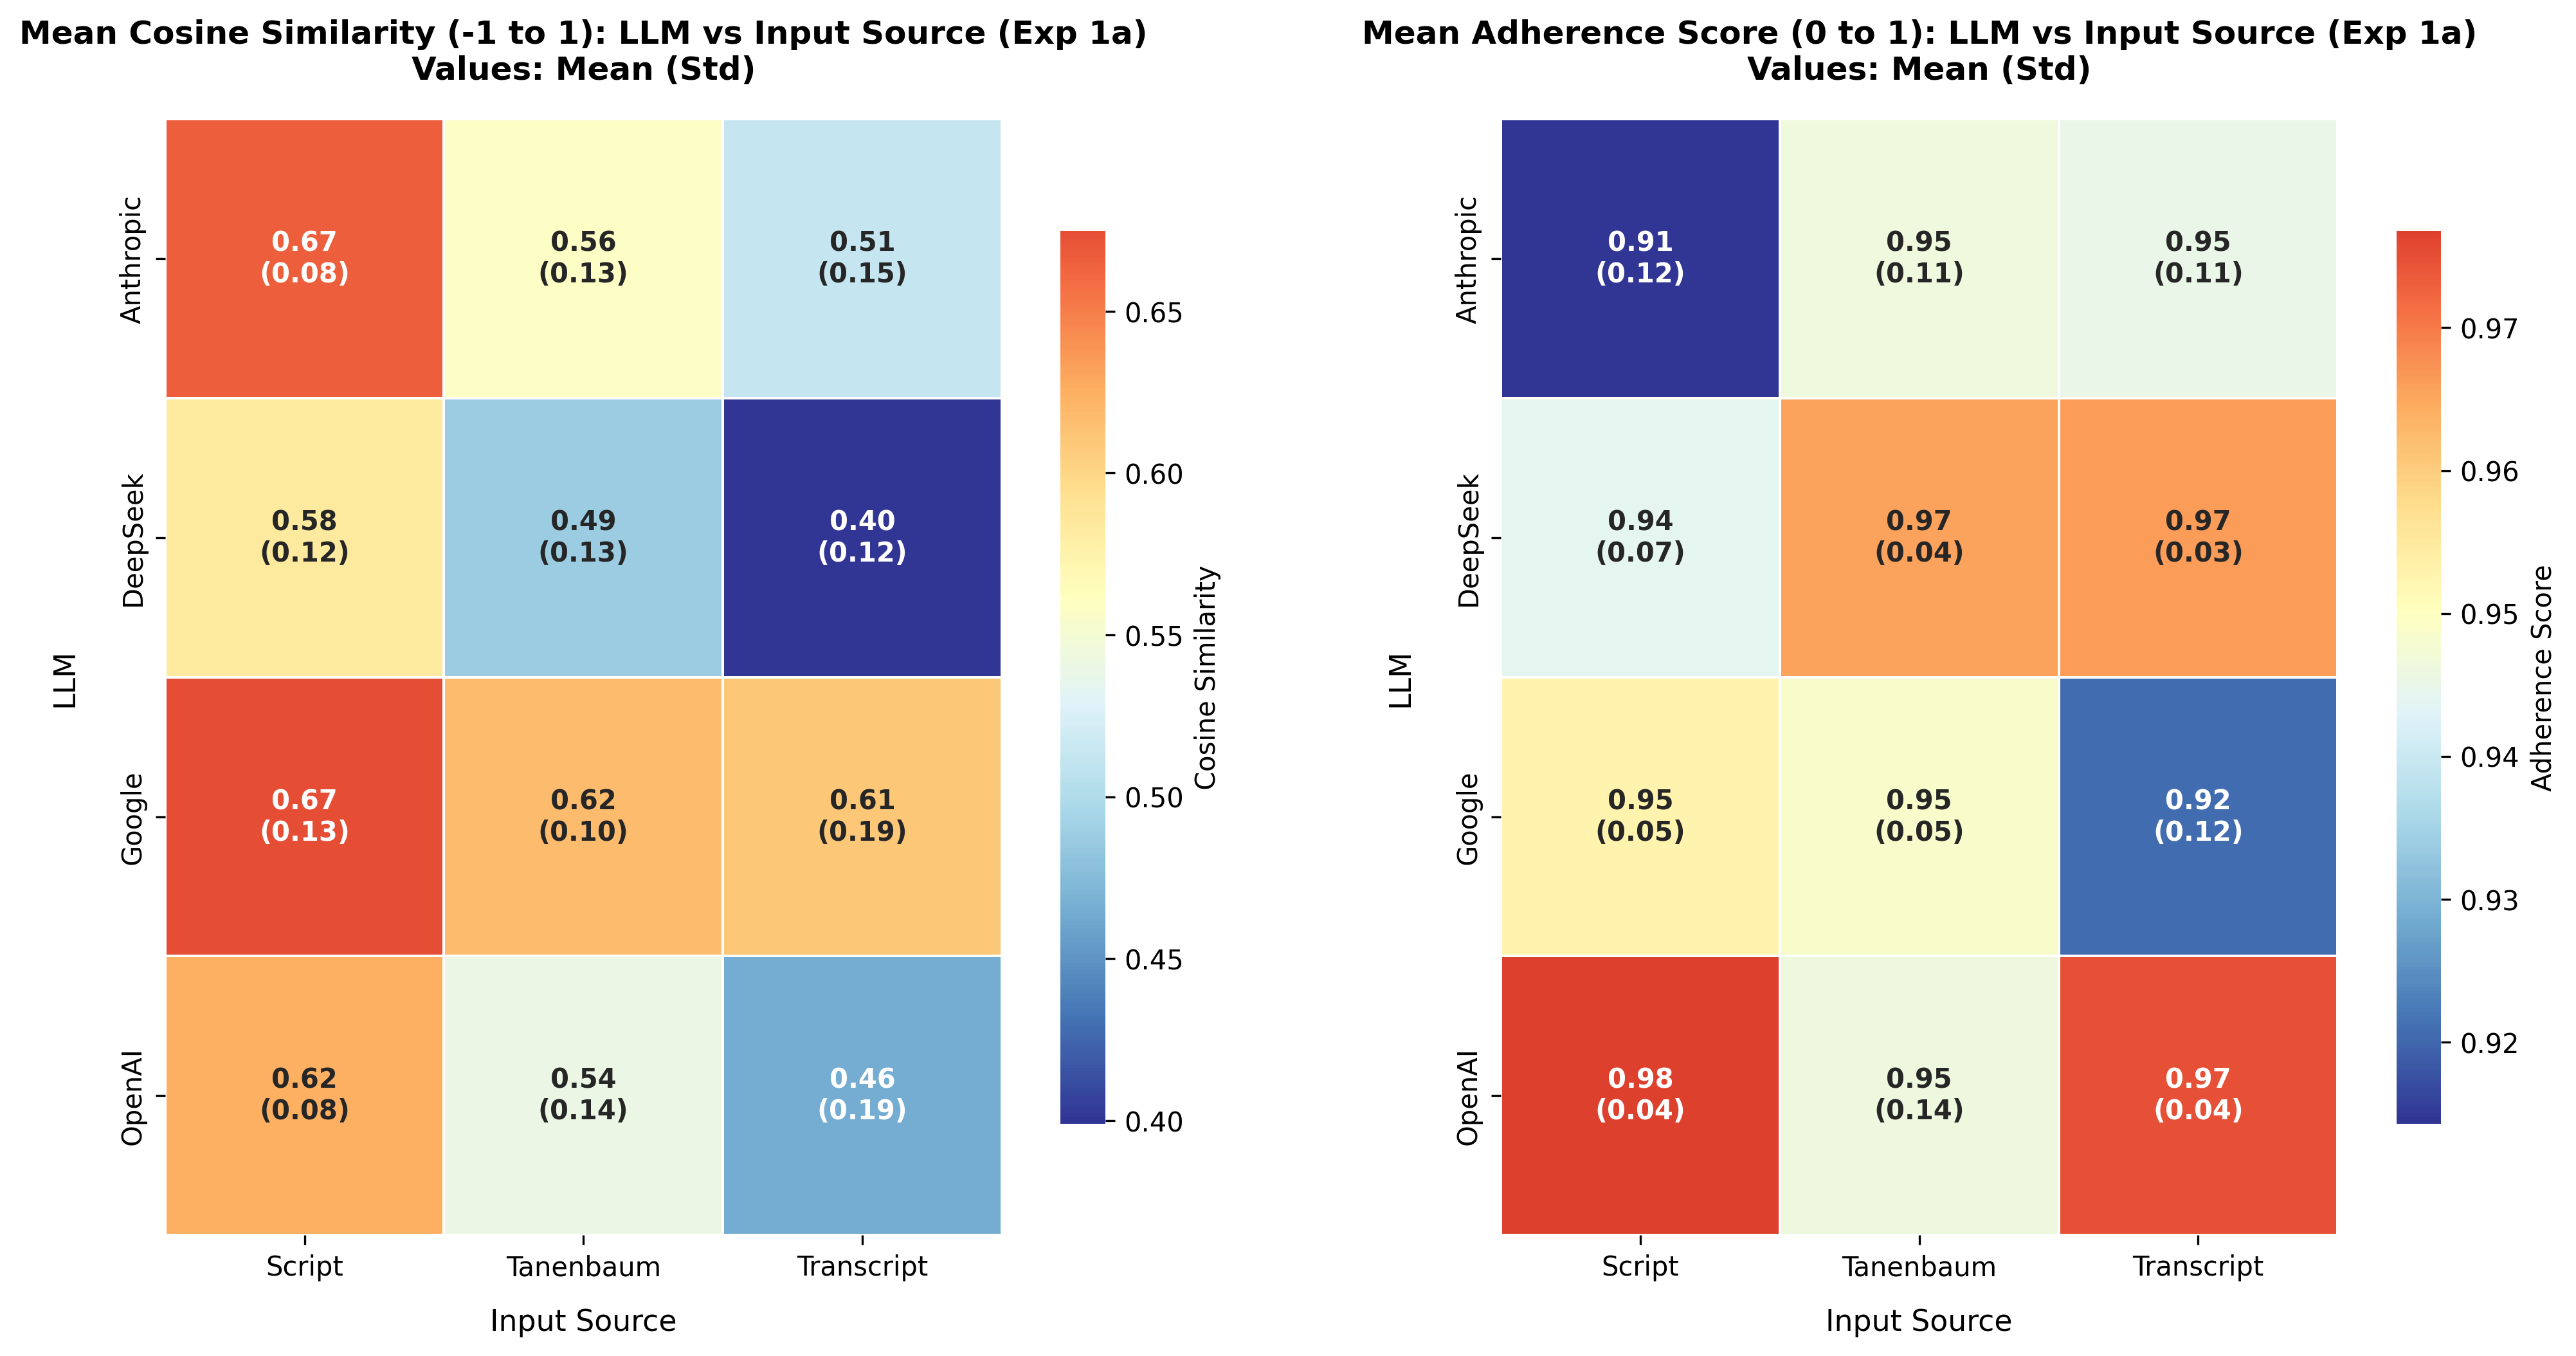

In [714]:
# TODO important die tendenz zum script
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
plots['exp1a_combined_llm_vs_input_source'] = fig

llm_vs_input_source_cos_sim_1a_display = llm_vs_input_source_cos_sim_1a["mean"].copy()
llm_vs_input_source_cos_sim_1a_std = llm_vs_input_source_cos_sim_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_cosine = llm_vs_input_source_cos_sim_1a_display.copy()
for i in range(len(llm_vs_input_source_cos_sim_1a_display.index)):
    for j in range(len(llm_vs_input_source_cos_sim_1a_display.columns)):
        mean_val = llm_vs_input_source_cos_sim_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_cos_sim_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_input_source_cos_sim_1a_display.index = llm_vs_input_source_cos_sim_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_input_source_cos_sim_1a_display.columns = llm_vs_input_source_cos_sim_1a_display.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})
annot_matrix_cosine.index = annot_matrix_cosine.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_cosine.columns = annot_matrix_cosine.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})

sns.heatmap(llm_vs_input_source_cos_sim_1a_display, 
            annot=annot_matrix_cosine, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_cos_sim_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Input Source", fontsize=11, labelpad=10)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)

llm_vs_input_source_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)

llm_vs_input_source_adherence_1a_display = llm_vs_input_source_adherence_1a["mean"].copy()
llm_vs_input_source_adherence_1a_std = llm_vs_input_source_adherence_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_adherence = llm_vs_input_source_adherence_1a_display.copy()
for i in range(len(llm_vs_input_source_adherence_1a_display.index)):
    for j in range(len(llm_vs_input_source_adherence_1a_display.columns)):
        mean_val = llm_vs_input_source_adherence_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_adherence_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_input_source_adherence_1a_display.index = llm_vs_input_source_adherence_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_input_source_adherence_1a_display.columns = llm_vs_input_source_adherence_1a_display.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})
annot_matrix_adherence.index = annot_matrix_adherence.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_adherence.columns = annot_matrix_adherence.columns.map({
    'script': 'Script', 'transcript': 'Transcript', 'tanenbaum': 'Tanenbaum'
})

sns.heatmap(llm_vs_input_source_adherence_1a_display, 
            annot=annot_matrix_adherence, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_adherence_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Input Source", fontsize=11, labelpad=10)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()


### 1.6: Cosine Similarity: LLM vs Prompt Type

In [715]:
llm_vs_prompt_type_cos_sim_1a = pd.pivot_table(
    exp1a_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1a
display(llm_vs_prompt_type_cos_sim_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.583207  0.574440  0.166589  0.101888
deepseek     0.485833  0.494285  0.141371  0.146142
google       0.580096  0.688457  0.158760  0.102245
openai       0.508703  0.577575  0.184646  0.111829

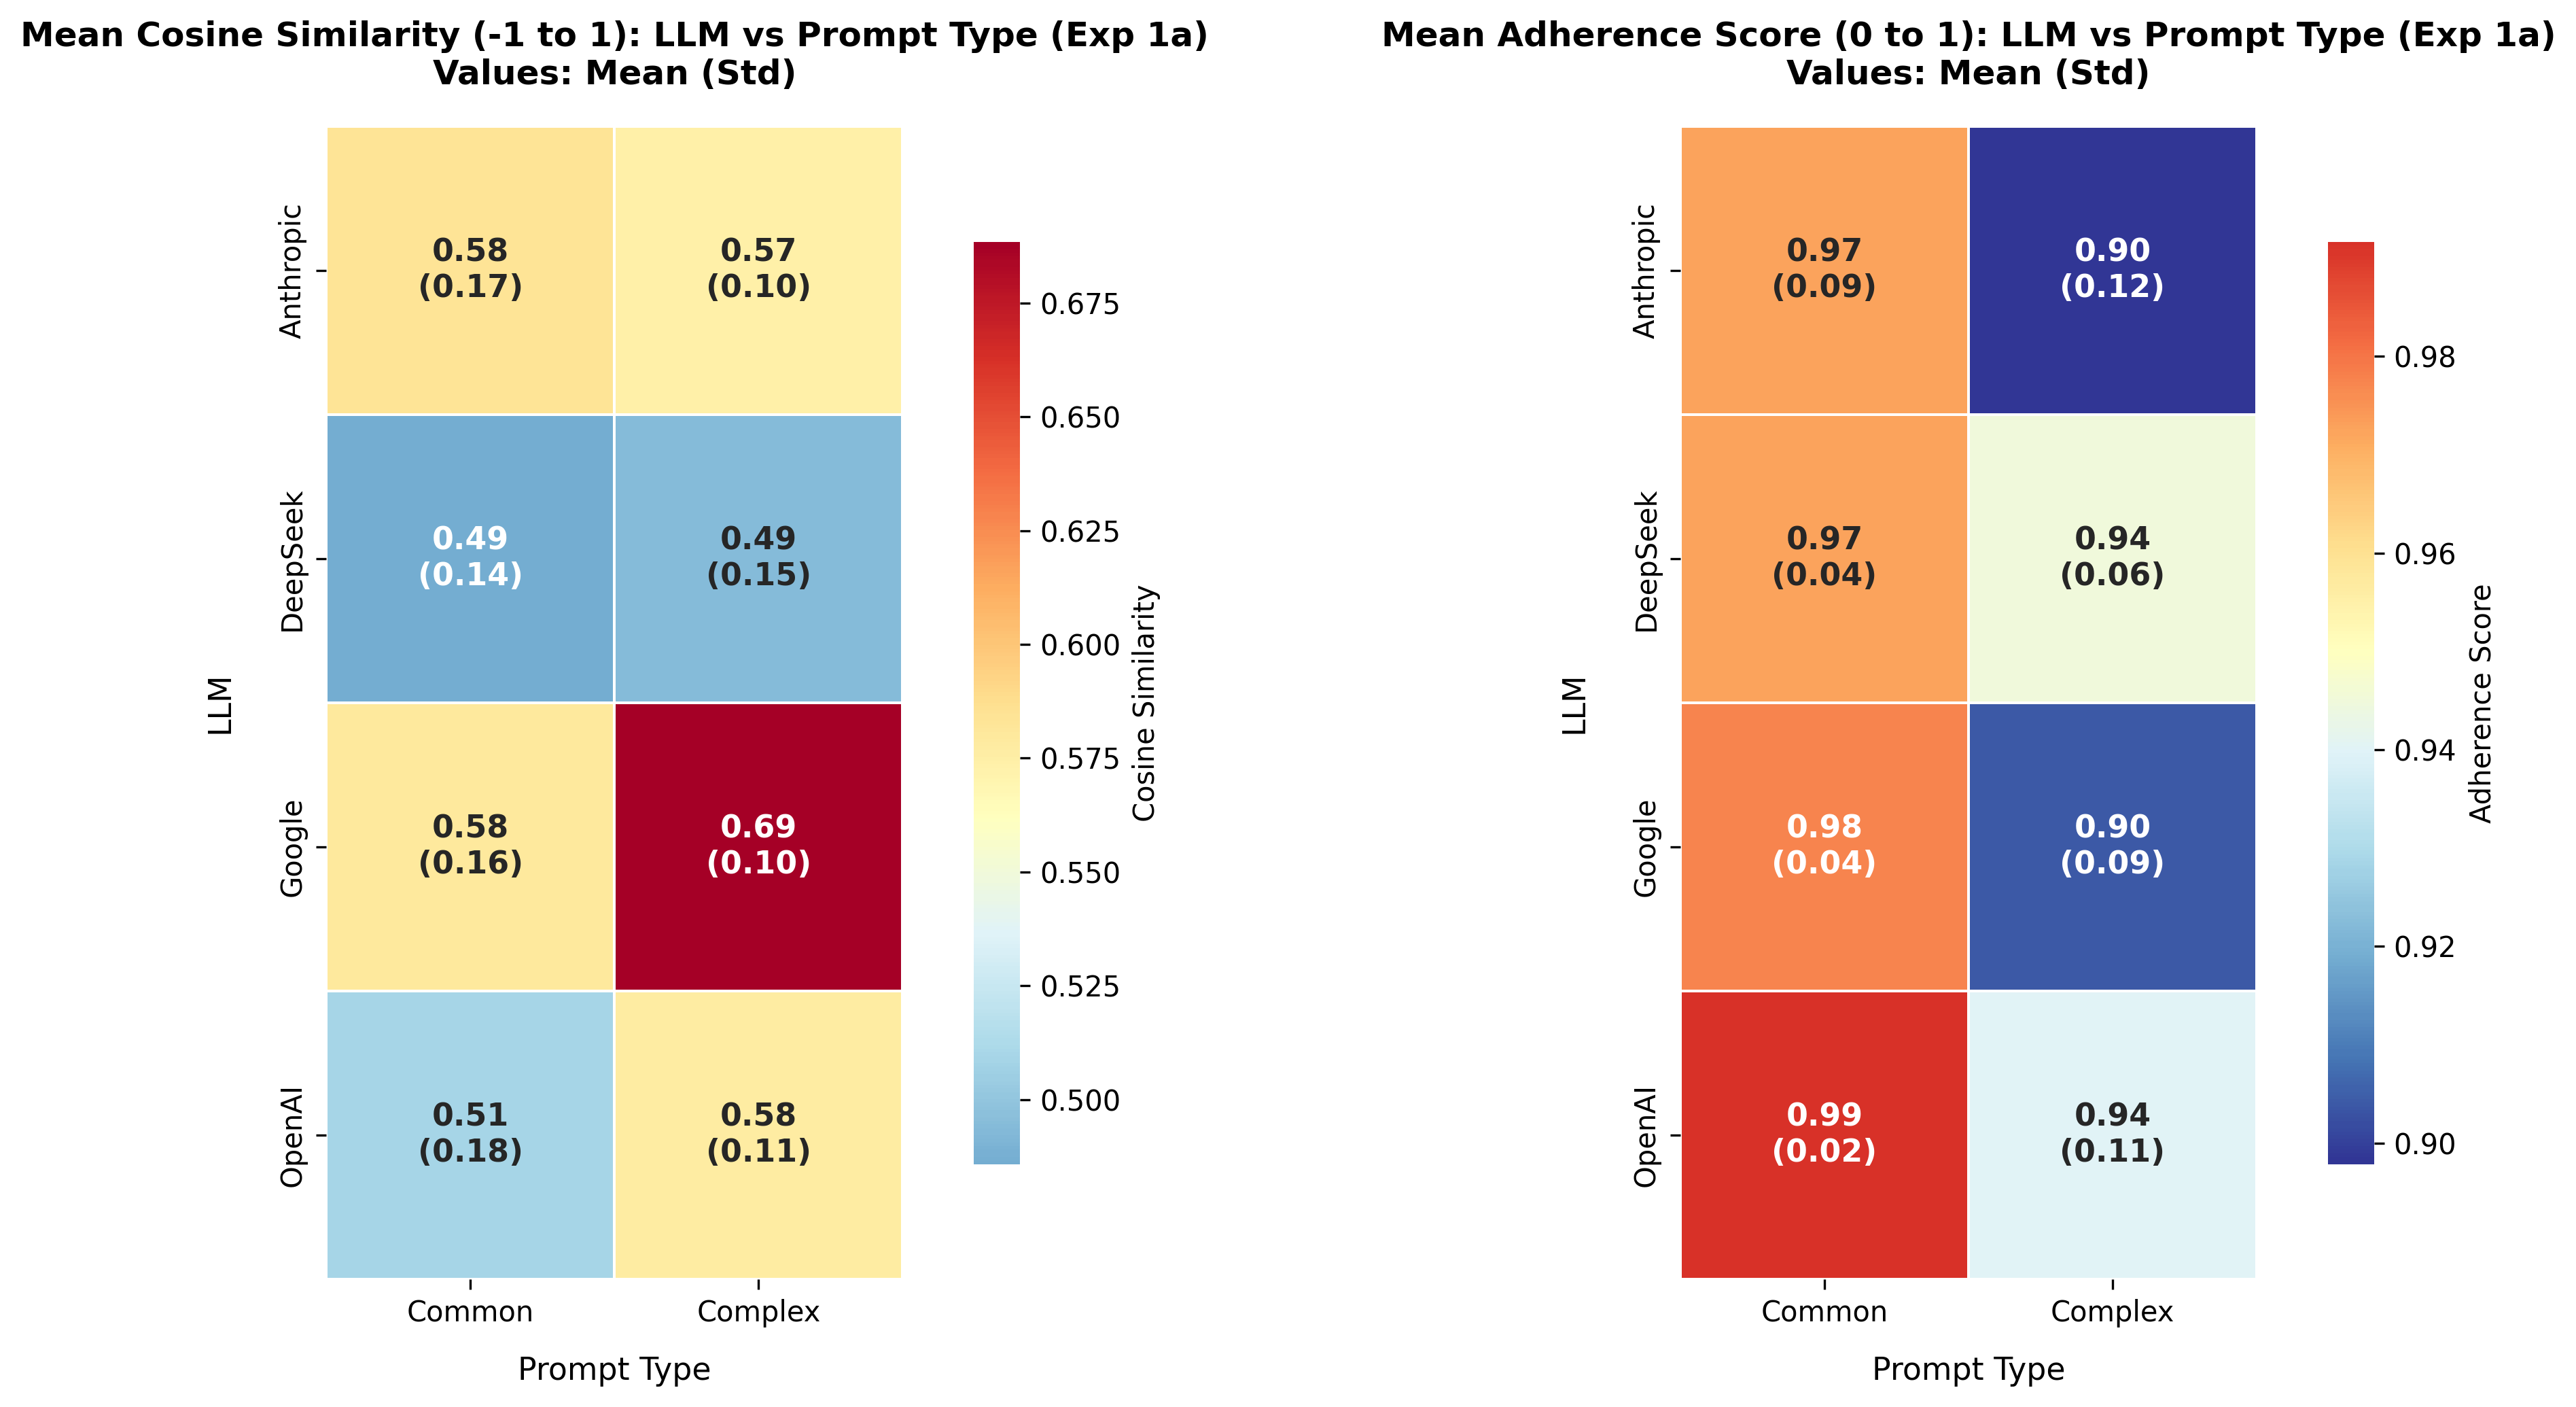

In [716]:
# Combined heatmaps: LLM vs Prompt Type (Exp 1a)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
plots['exp1a_combined_llm_vs_prompt_type'] = fig

llm_vs_prompt_type_cos_sim_1a_display = llm_vs_prompt_type_cos_sim_1a["mean"].copy()
llm_vs_prompt_type_cos_sim_1a_std = llm_vs_prompt_type_cos_sim_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_cosine_prompt = llm_vs_prompt_type_cos_sim_1a_display.copy()
for i in range(len(llm_vs_prompt_type_cos_sim_1a_display.index)):
    for j in range(len(llm_vs_prompt_type_cos_sim_1a_display.columns)):
        mean_val = llm_vs_prompt_type_cos_sim_1a_display.iloc[i, j]
        std_val = llm_vs_prompt_type_cos_sim_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine_prompt.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine_prompt.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_cos_sim_1a_display.index = llm_vs_prompt_type_cos_sim_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_cos_sim_1a_display.columns = llm_vs_prompt_type_cos_sim_1a_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_cosine_prompt.index = annot_matrix_cosine_prompt.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_cosine_prompt.columns = annot_matrix_cosine_prompt.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_cos_sim_1a_display, 
            annot=annot_matrix_cosine_prompt, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_cos_sim_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Prompt Type (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)

llm_vs_prompt_type_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)

llm_vs_prompt_type_adherence_1a_display = llm_vs_prompt_type_adherence_1a["mean"].copy()
llm_vs_prompt_type_adherence_1a_std = llm_vs_prompt_type_adherence_1a["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_adherence_prompt = llm_vs_prompt_type_adherence_1a_display.copy()
for i in range(len(llm_vs_prompt_type_adherence_1a_display.index)):
    for j in range(len(llm_vs_prompt_type_adherence_1a_display.columns)):
        mean_val = llm_vs_prompt_type_adherence_1a_display.iloc[i, j]
        std_val = llm_vs_prompt_type_adherence_1a_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence_prompt.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence_prompt.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_adherence_1a_display.index = llm_vs_prompt_type_adherence_1a_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_adherence_1a_display.columns = llm_vs_prompt_type_adherence_1a_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_adherence_prompt.index = annot_matrix_adherence_prompt.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_adherence_prompt.columns = annot_matrix_adherence_prompt.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_adherence_1a_display, 
            annot=annot_matrix_adherence_prompt, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_adherence_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Prompt Type (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()


### 1.7: Adherence Score: LLM vs Prompt Type

In [717]:
llm_vs_prompt_type_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_prompt_type"] = llm_vs_prompt_type_adherence_1a
display(llm_vs_prompt_type_adherence_1a)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.972619  0.897857  0.093843  0.116249
deepseek     0.972619  0.944762  0.036797  0.057781
google       0.977381  0.904048  0.043778  0.090286
openai       0.991667  0.940000  0.015995  0.112761

### 1.8: Adherence Score: LLM vs Input Source

In [718]:
llm_vs_input_source_adherence_1a = pd.pivot_table(
    exp1a_df,
    values="adherence_score",
    index="llm",
    columns="input_source",
    aggfunc=["mean", "std"],
)
tables["exp1a_adherence_llm_vs_input_source"] = llm_vs_input_source_adherence_1a
display(llm_vs_input_source_adherence_1a)

mean                            std                     
input_source    script tanenbaum transcript    script tanenbaum transcript
llm                                                                       
anthropic     0.914286  0.946429   0.945000  0.115806  0.111017   0.111390
deepseek      0.944286  0.965714   0.966071  0.066762  0.043847   0.033637
google        0.952857  0.948571   0.920714  0.051168  0.054647   0.116501
openai        0.976786  0.946071   0.974643  0.037293  0.137284   0.035217

### 1.9: Distribution Plots

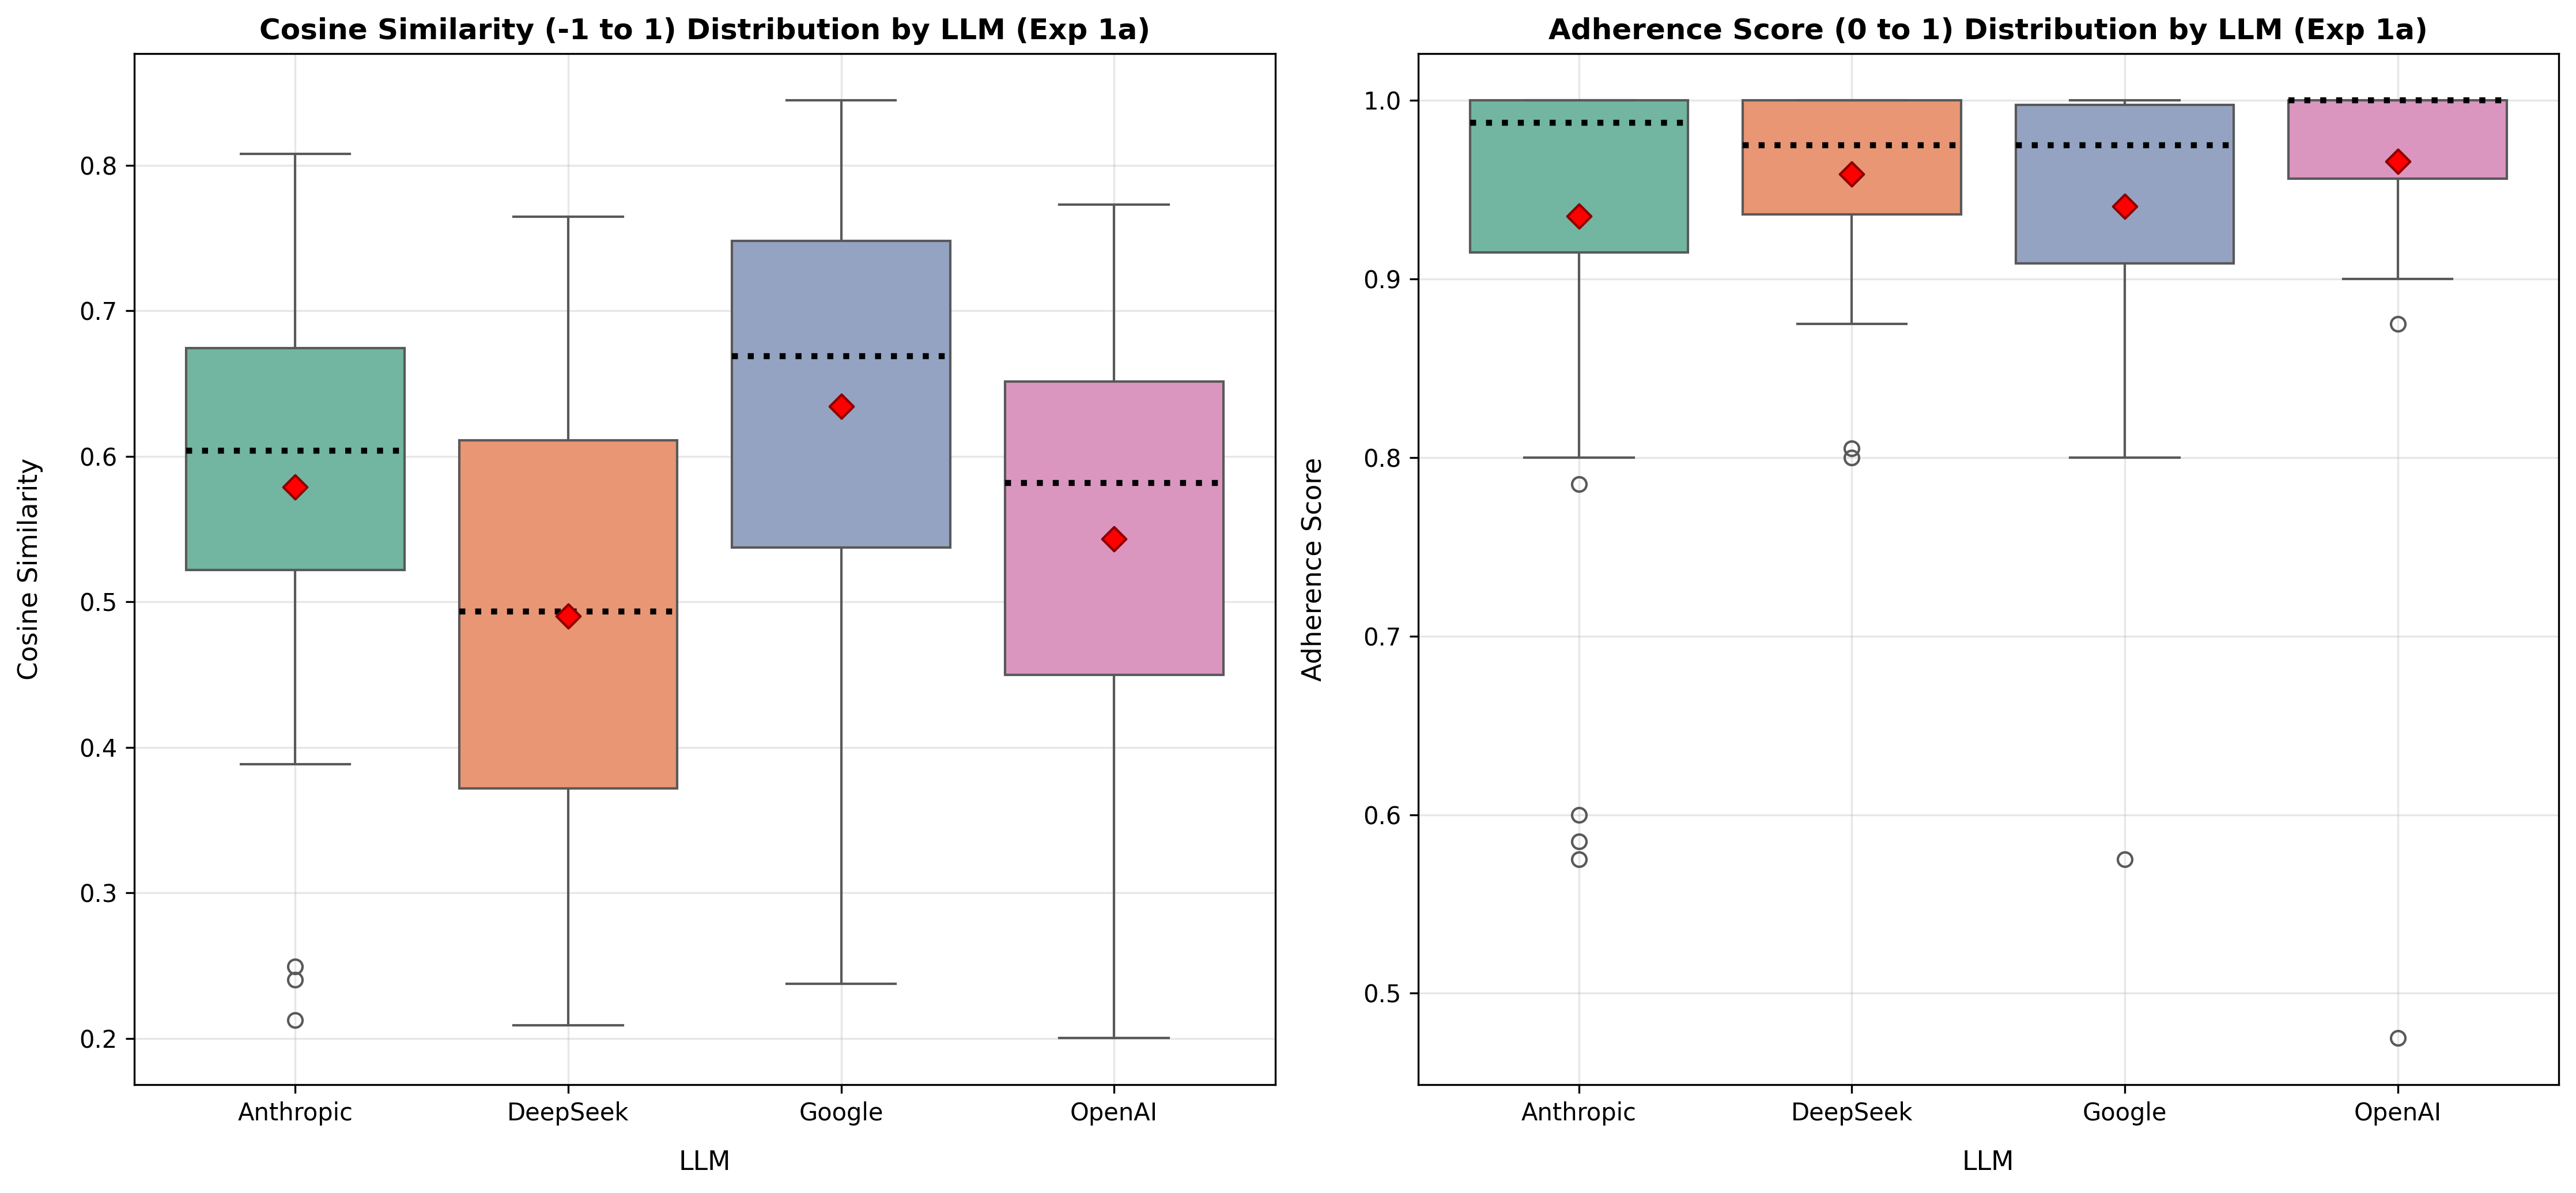

In [719]:
# Boxplot for cosine_similarity and adherence_score by LLM
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_llm'] = fig

create_seaborn_boxplot(exp1a_df, 'llm', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by LLM (Exp 1a)',
                      'Cosine Similarity', 'LLM')

create_seaborn_boxplot(exp1a_df, 'llm', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by LLM (Exp 1a)', 
                      'Adherence Score', 'LLM')

plt.tight_layout()
plt.show()


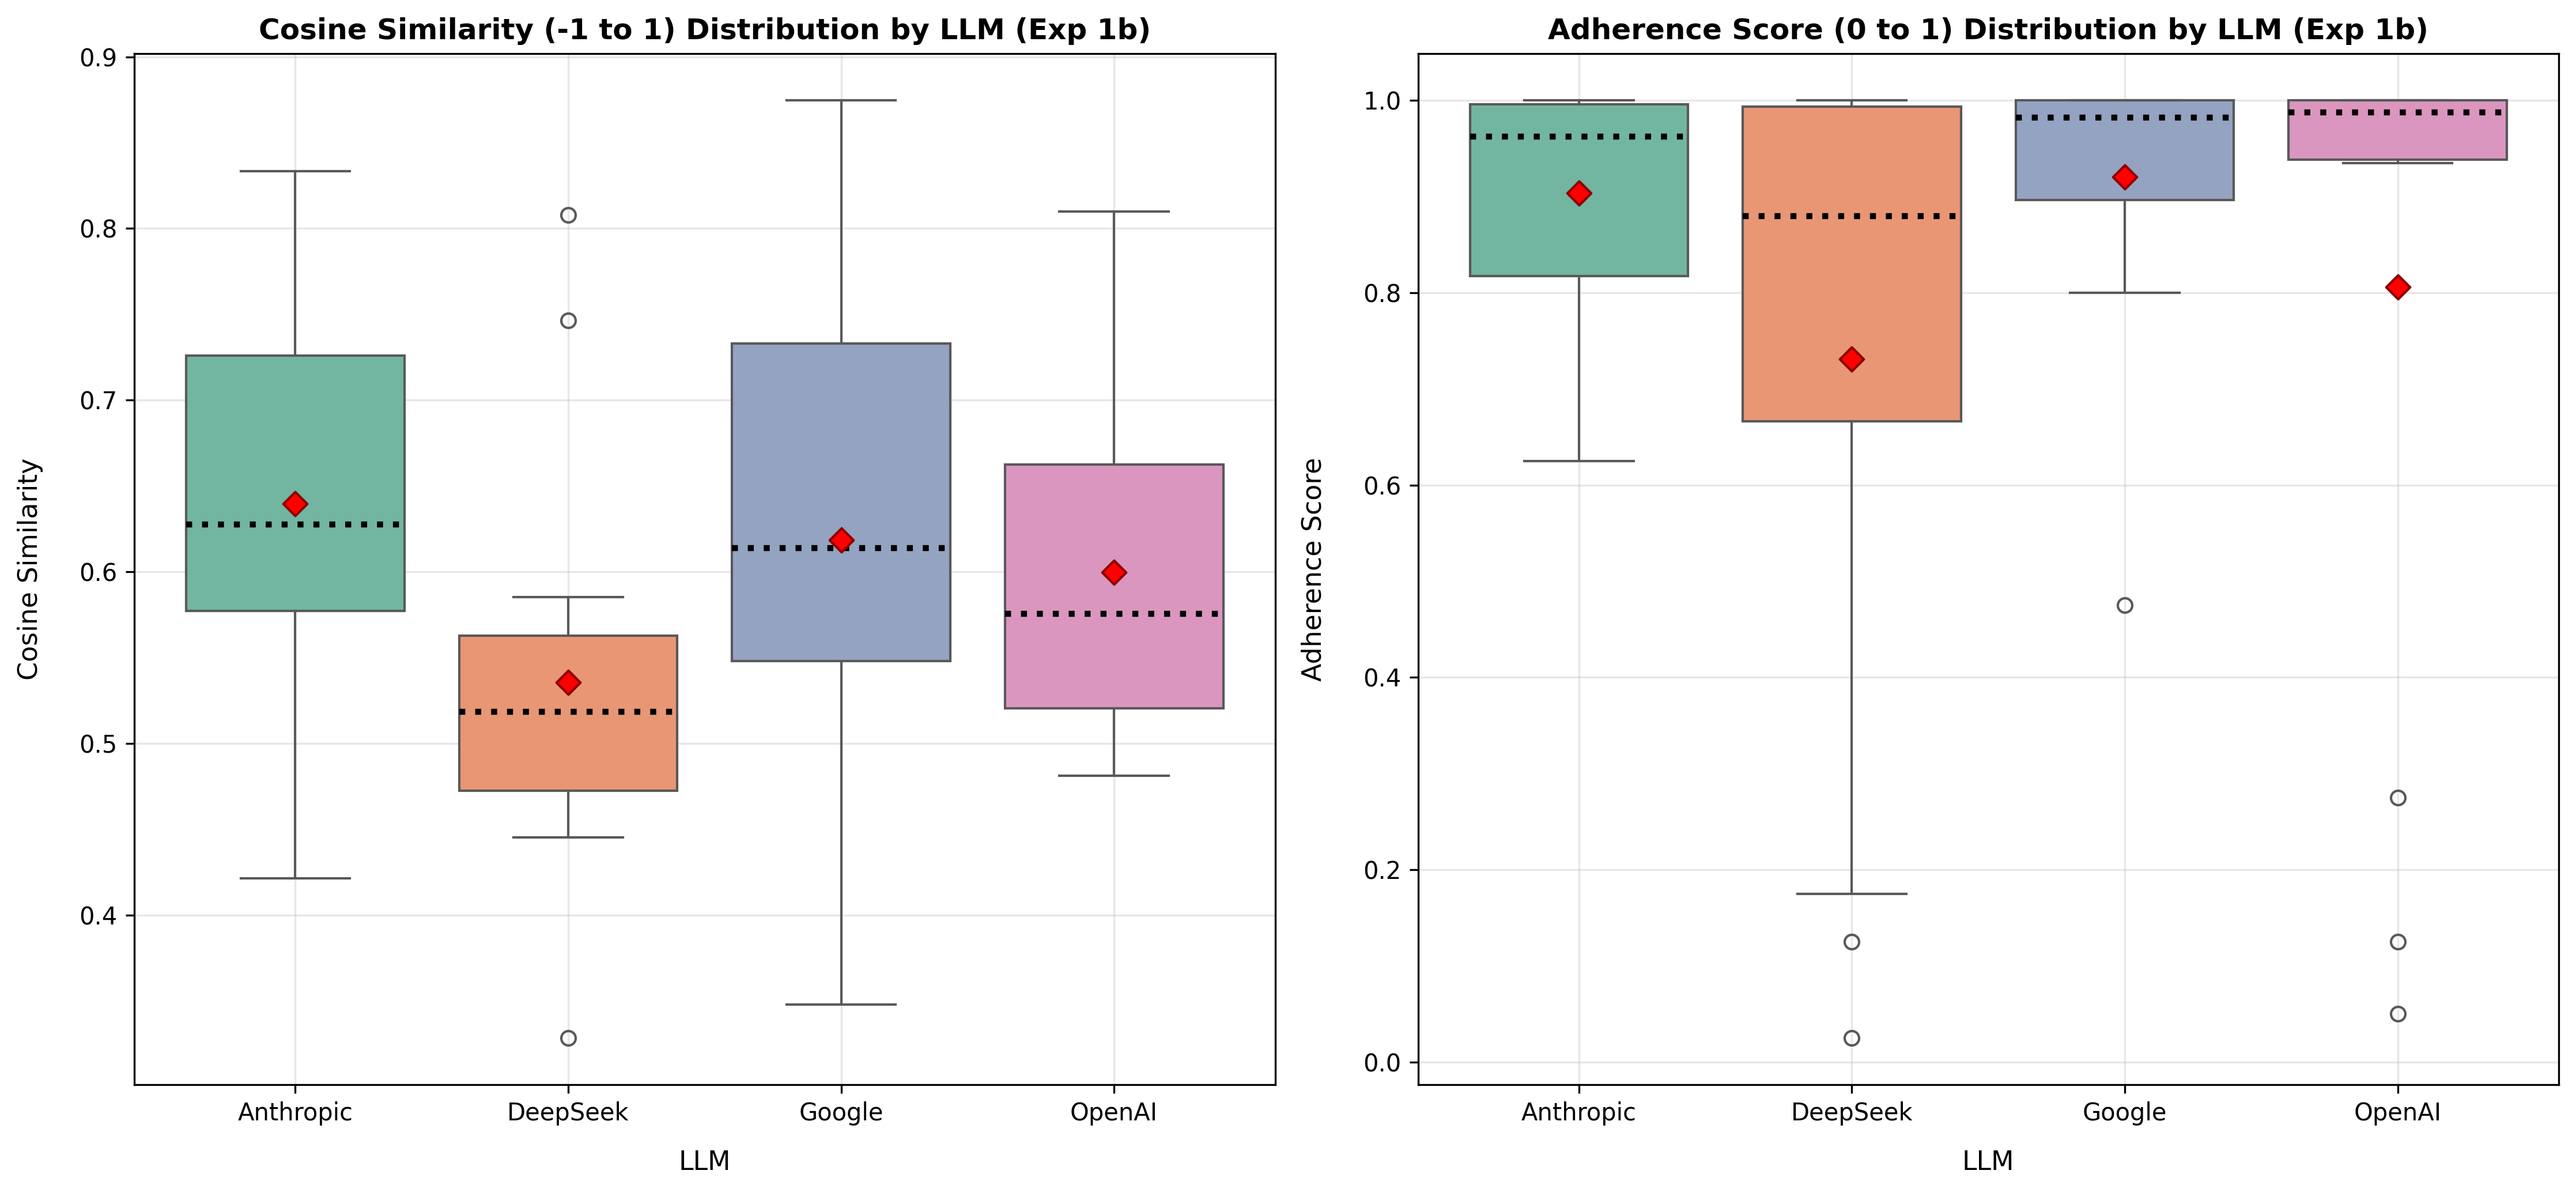

In [720]:
# Boxplot for cosine_similarity and adherence_score by LLM
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1b_dist_by_llm'] = fig

create_seaborn_boxplot(exp1b_df, 'llm', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by LLM (Exp 1b)',
                      'Cosine Similarity', 'LLM')

create_seaborn_boxplot(exp1b_df, 'llm', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by LLM (Exp 1b)', 
                      'Adherence Score', 'LLM')

plt.tight_layout()
plt.show()


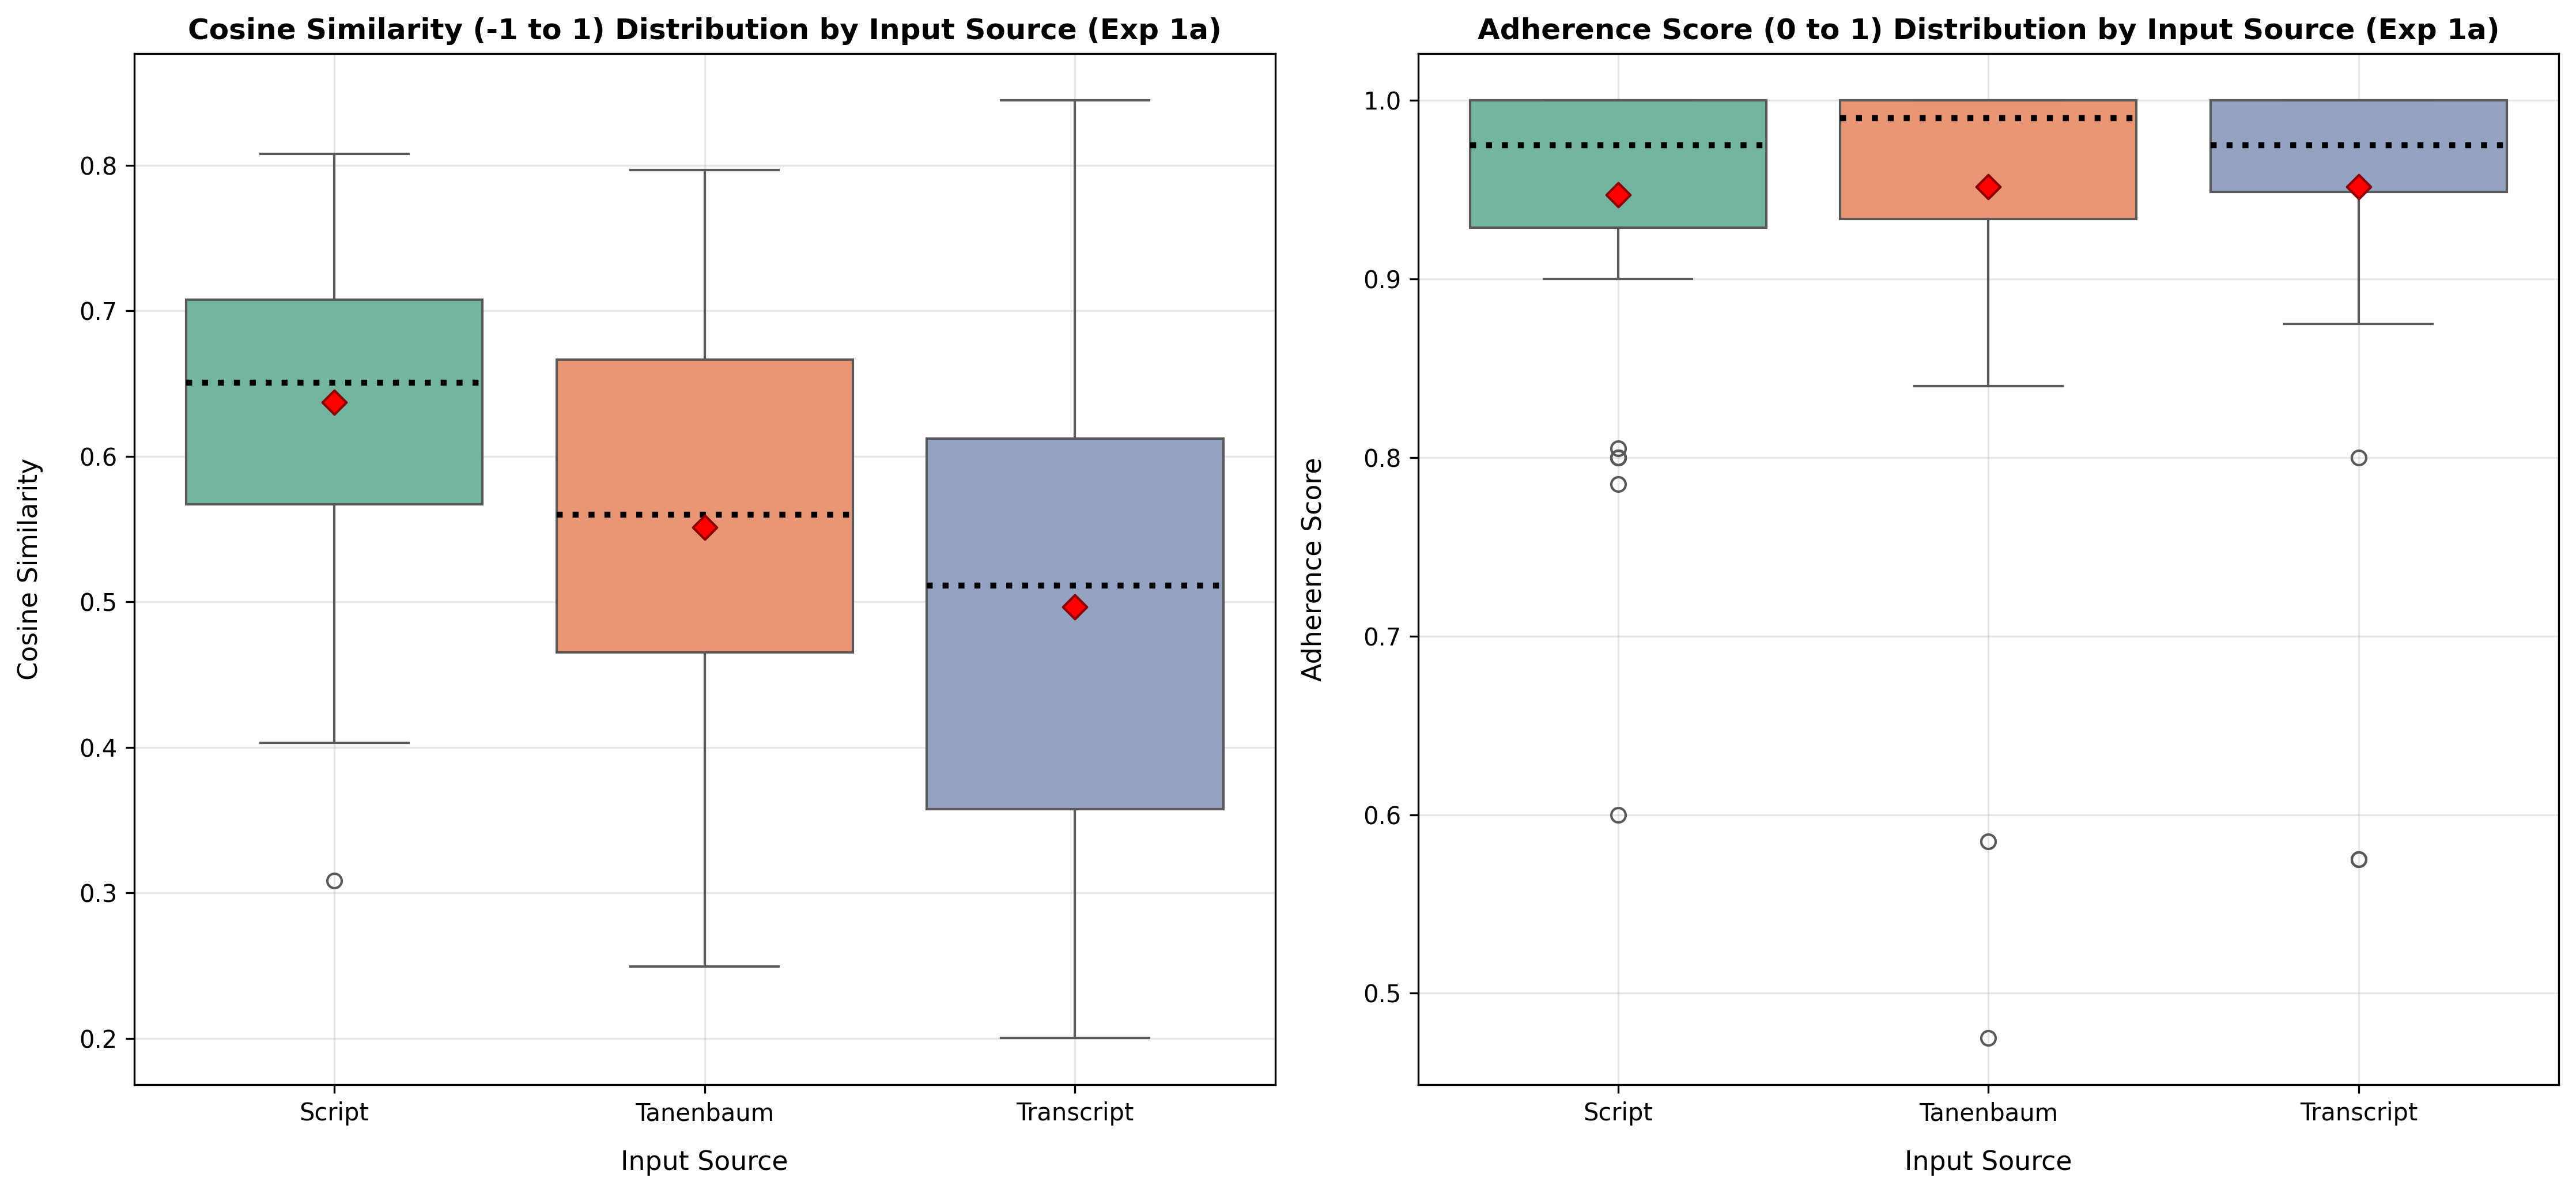

In [721]:
# OPTIONAL: Boxplot for cosine_similarity and adherence_score by input_source (no source coupling is another plot)
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plots['exp1a_dist_by_input_source'] = fig

create_seaborn_boxplot(exp1a_df, 'input_source', 'cosine_similarity', ax[0], 
                      'Cosine Similarity (-1 to 1) Distribution by Input Source (Exp 1a)',
                      'Cosine Similarity', 'Input Source')

create_seaborn_boxplot(exp1a_df, 'input_source', 'adherence_score', ax[1],
                      'Adherence Score (0 to 1) Distribution by Input Source (Exp 1a)', 
                      'Adherence Score', 'Input Source')

plt.tight_layout()
plt.show()

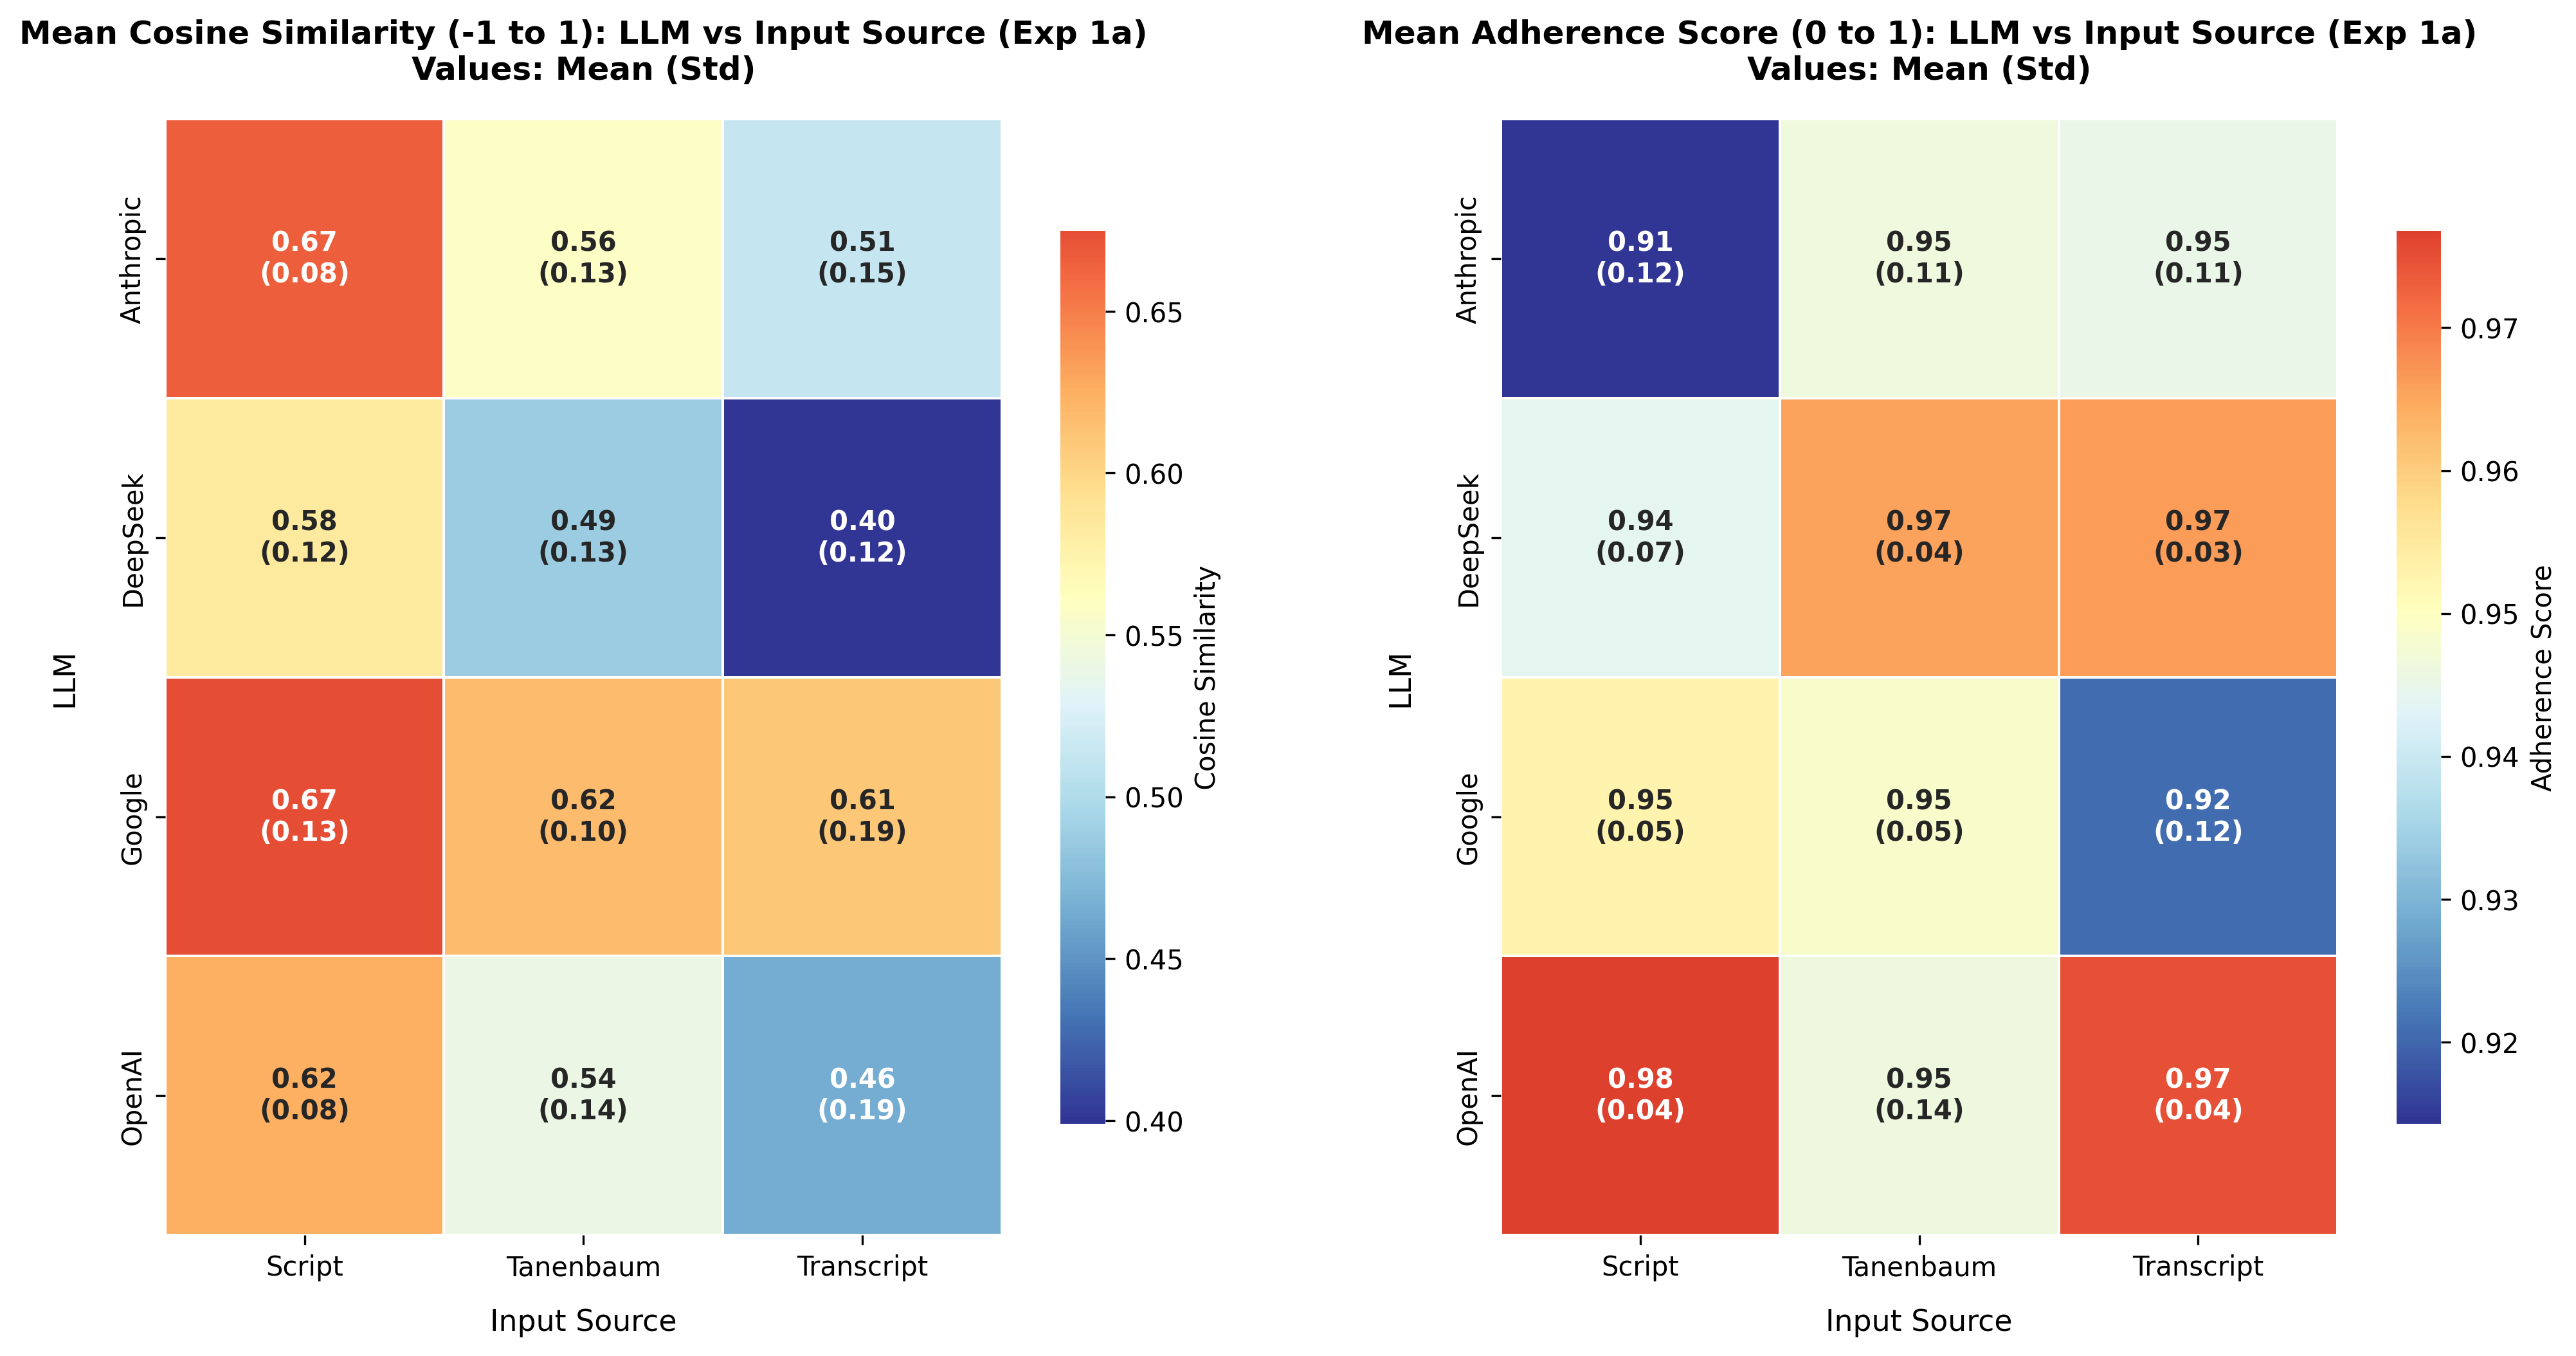

In [722]:
# Updated combined heatmap section
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# For cosine similarity
llm_vs_input_source_cos_sim_1a_std_final = llm_vs_input_source_cos_sim_1a["std"].copy()
annot_matrix_cosine_final = llm_vs_input_source_cos_sim_1a_display.copy()
for i in range(len(llm_vs_input_source_cos_sim_1a_display.index)):
    for j in range(len(llm_vs_input_source_cos_sim_1a_display.columns)):
        mean_val = llm_vs_input_source_cos_sim_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_cos_sim_1a_std_final.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine_final.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine_final.iloc[i, j] = f"{mean_val:.2f}"

sns.heatmap(llm_vs_input_source_cos_sim_1a_display, 
            annot=annot_matrix_cosine_final, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_cos_sim_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)
ax1.set_xlabel("Input Source", fontsize=11, labelpad=10)

# For adherence score
llm_vs_input_source_adherence_1a_std_final = llm_vs_input_source_adherence_1a["std"].copy()
annot_matrix_adherence_final = llm_vs_input_source_adherence_1a_display.copy()
for i in range(len(llm_vs_input_source_adherence_1a_display.index)):
    for j in range(len(llm_vs_input_source_adherence_1a_display.columns)):
        mean_val = llm_vs_input_source_adherence_1a_display.iloc[i, j]
        std_val = llm_vs_input_source_adherence_1a_std_final.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence_final.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence_final.iloc[i, j] = f"{mean_val:.2f}"

sns.heatmap(llm_vs_input_source_adherence_1a_display, 
            annot=annot_matrix_adherence_final, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_input_source_adherence_1a_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Input Source (Exp 1a)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)
ax2.set_xlabel("Input Source", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()


## Experiment 1b

### 2.1: Metrics by LLM

In [723]:
llm_metrics_1b = exp1b_df.groupby("llm")[["cosine_similarity", "adherence_score"]].agg(
    ["mean", "std"]
)
tables["exp1b_metrics_by_llm"] = llm_metrics_1b
display(llm_metrics_1b)


cosine_similarity           adherence_score          
                       mean       std            mean       std
llm                                                            
anthropic          0.639624  0.120503        0.903571  0.123186
deepseek           0.535659  0.120614        0.731071  0.355929
google             0.618493  0.155956        0.920357  0.142942
openai             0.599776  0.107091        0.806071  0.358974

### 2.6: Cosine Similarity & Adherence: LLM vs Prompt Type

In [724]:
llm_vs_prompt_type_cos_sim_1b = pd.pivot_table(
    exp1b_df,
    values="cosine_similarity",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)
tables["exp1b_cosine_sim_llm_vs_prompt_type"] = llm_vs_prompt_type_cos_sim_1b
display(llm_vs_prompt_type_cos_sim_1b)

mean                 std          
prompt_type    common   complex    common   complex
llm                                                
anthropic    0.702068  0.577180  0.139379  0.054194
deepseek     0.532872  0.538446  0.123492  0.127482
google       0.648236  0.588749  0.150385  0.167388
openai       0.601861  0.597690  0.100315  0.121553

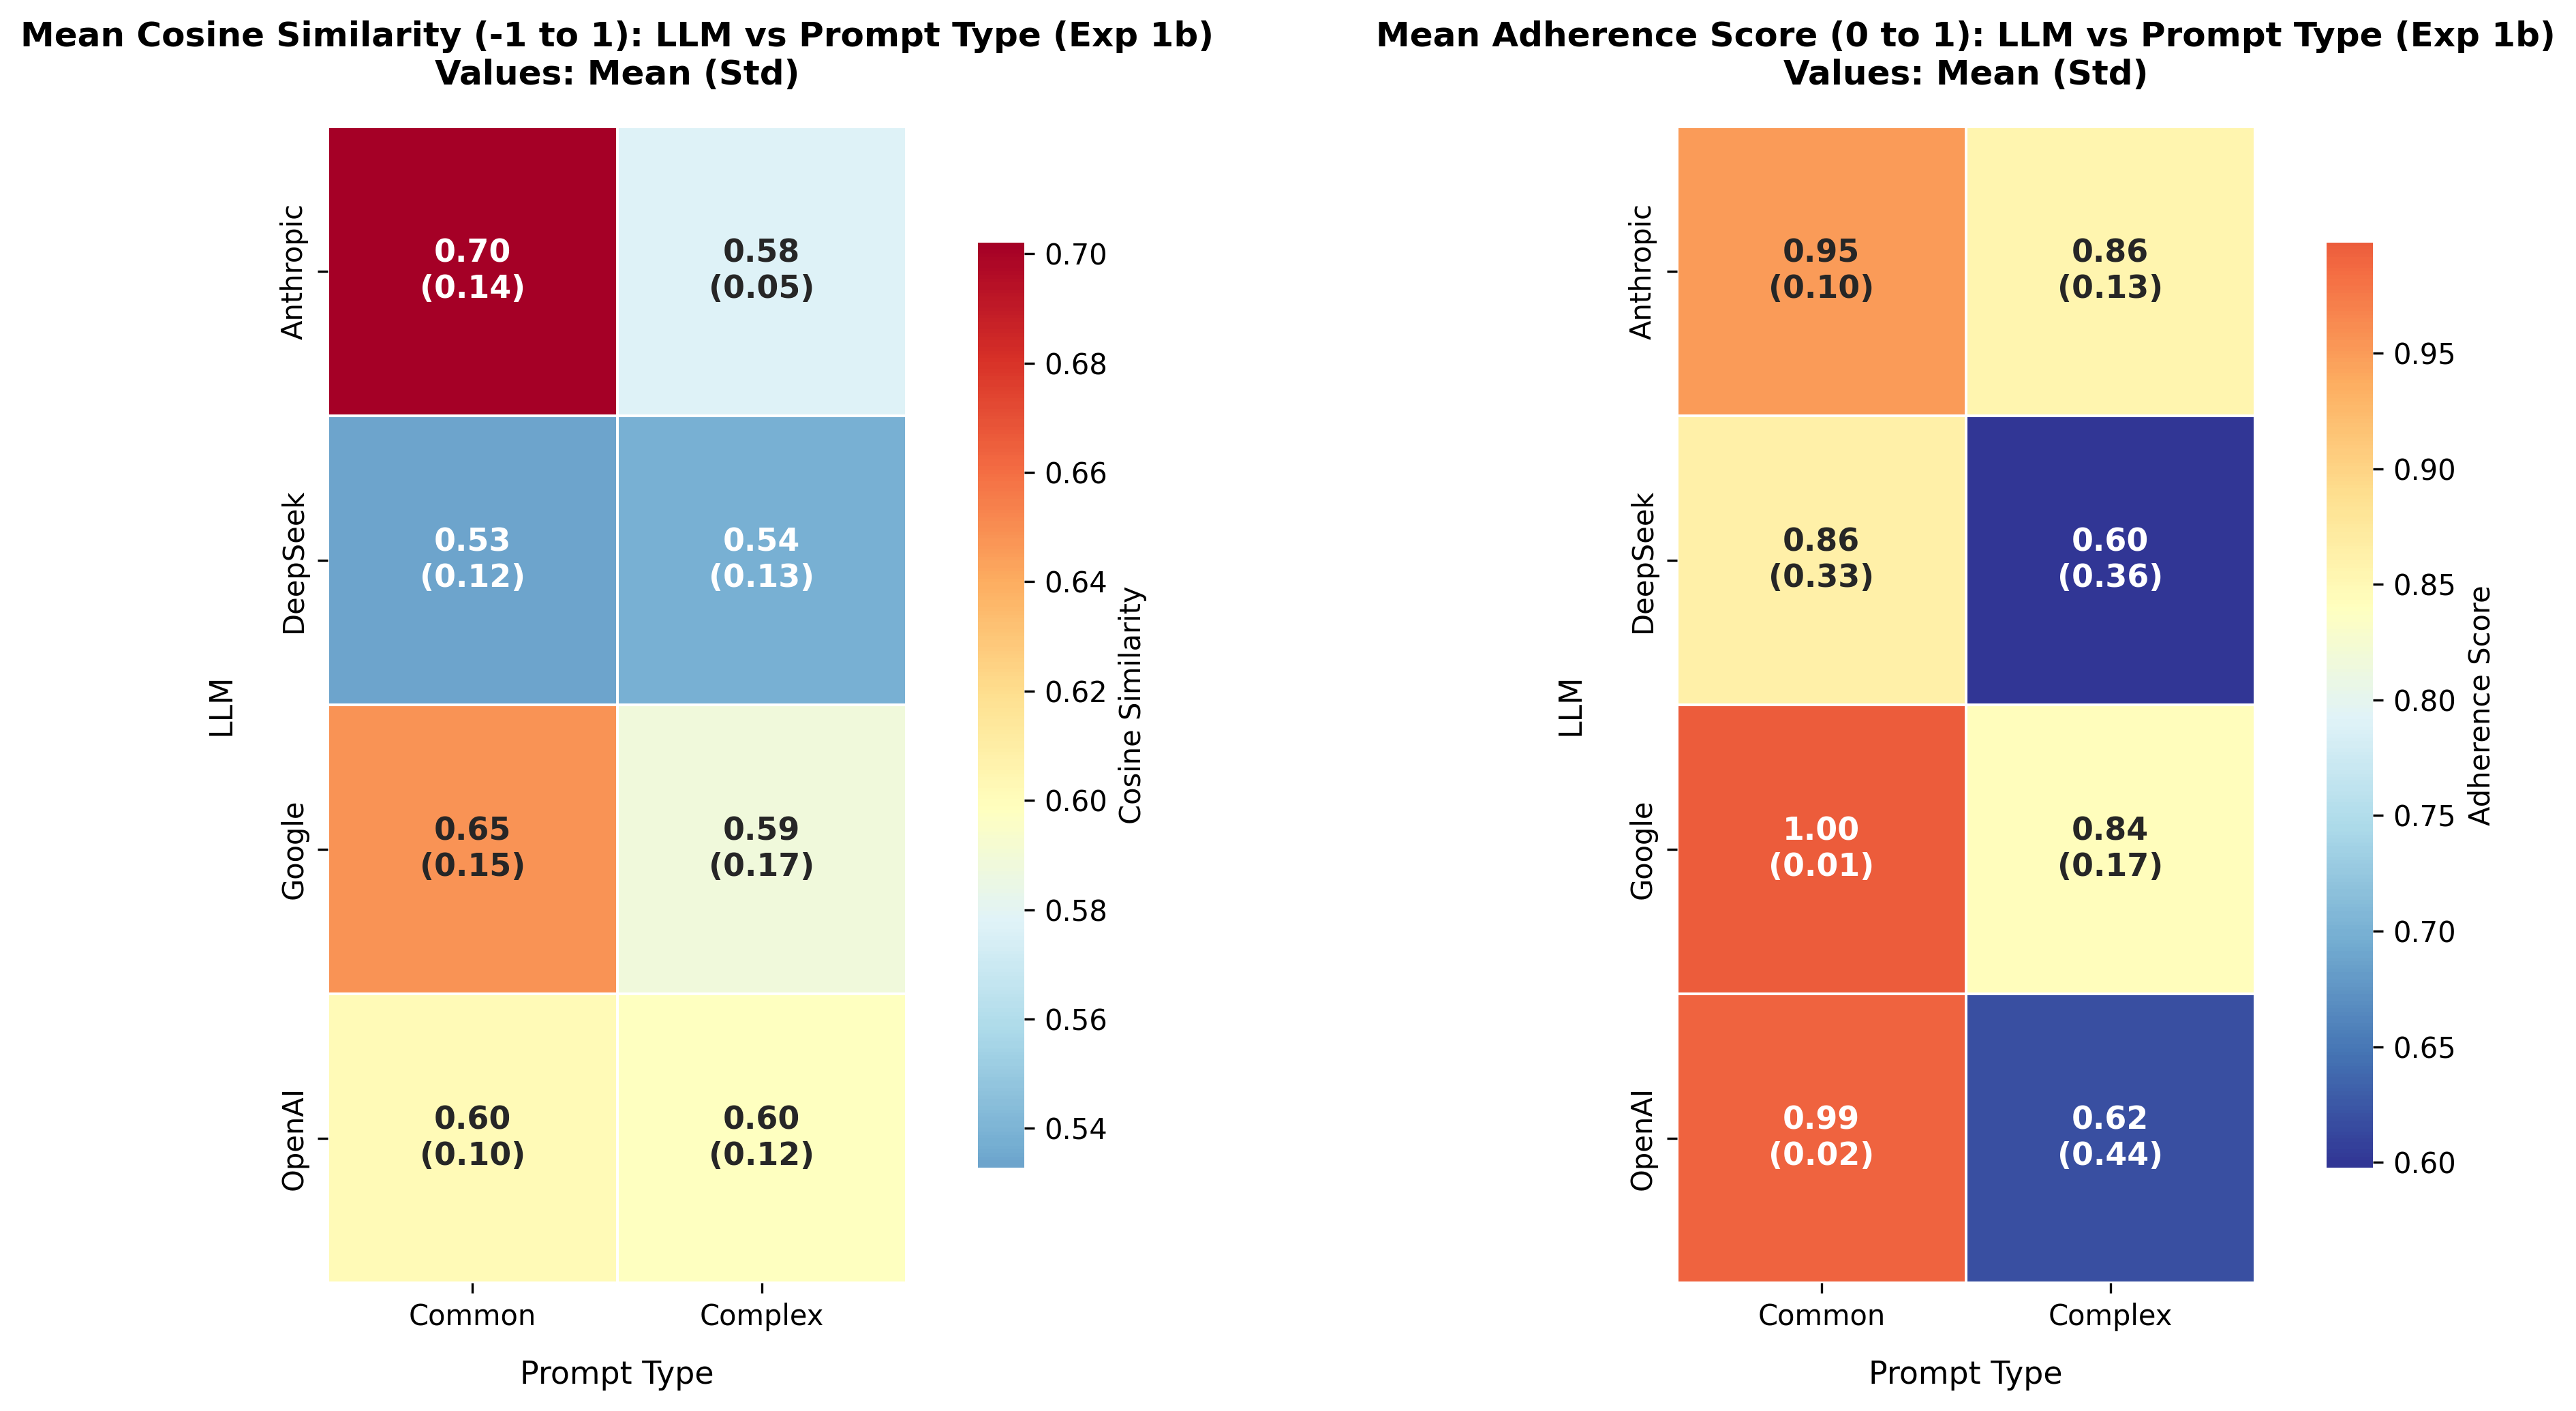

In [725]:
# Combined heatmaps: LLM vs Prompt Type (Exp 1b)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
plots['exp1b_combined_llm_vs_prompt_type'] = fig

llm_vs_prompt_type_cos_sim_1b_display = llm_vs_prompt_type_cos_sim_1b["mean"].copy()
llm_vs_prompt_type_cos_sim_1b_std = llm_vs_prompt_type_cos_sim_1b["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_cosine_prompt_1b = llm_vs_prompt_type_cos_sim_1b_display.copy()
for i in range(len(llm_vs_prompt_type_cos_sim_1b_display.index)):
    for j in range(len(llm_vs_prompt_type_cos_sim_1b_display.columns)):
        mean_val = llm_vs_prompt_type_cos_sim_1b_display.iloc[i, j]
        std_val = llm_vs_prompt_type_cos_sim_1b_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_cosine_prompt_1b.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_cosine_prompt_1b.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_cos_sim_1b_display.index = llm_vs_prompt_type_cos_sim_1b_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_cos_sim_1b_display.columns = llm_vs_prompt_type_cos_sim_1b_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_cosine_prompt_1b.index = annot_matrix_cosine_prompt_1b.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_cosine_prompt_1b.columns = annot_matrix_cosine_prompt_1b.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_cos_sim_1b_display, 
            annot=annot_matrix_cosine_prompt_1b, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_cos_sim_1b_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax1)
ax1.set_title("Mean Cosine Similarity (-1 to 1): LLM vs Prompt Type (Exp 1b)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax1.set_ylabel("LLM", fontsize=11, labelpad=15)

llm_vs_prompt_type_adherence_1b = pd.pivot_table(
    exp1b_df,
    values="adherence_score",
    index="llm",
    columns="prompt_type",
    aggfunc=["mean", "std"],
)

llm_vs_prompt_type_adherence_1b_display = llm_vs_prompt_type_adherence_1b["mean"].copy()
llm_vs_prompt_type_adherence_1b_std = llm_vs_prompt_type_adherence_1b["std"].copy()

# Create annotation matrix with mean and std
annot_matrix_adherence_prompt_1b = llm_vs_prompt_type_adherence_1b_display.copy()
for i in range(len(llm_vs_prompt_type_adherence_1b_display.index)):
    for j in range(len(llm_vs_prompt_type_adherence_1b_display.columns)):
        mean_val = llm_vs_prompt_type_adherence_1b_display.iloc[i, j]
        std_val = llm_vs_prompt_type_adherence_1b_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_adherence_prompt_1b.iloc[i, j] = f"{mean_val:.2f}\n({std_val:.2f})"
        elif pd.notna(mean_val):
            annot_matrix_adherence_prompt_1b.iloc[i, j] = f"{mean_val:.2f}"

llm_vs_prompt_type_adherence_1b_display.index = llm_vs_prompt_type_adherence_1b_display.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
llm_vs_prompt_type_adherence_1b_display.columns = llm_vs_prompt_type_adherence_1b_display.columns.map({
    'common': 'Common', 'complex': 'Complex'
})
annot_matrix_adherence_prompt_1b.index = annot_matrix_adherence_prompt_1b.index.map({
    'anthropic': 'Anthropic', 'openai': 'OpenAI', 'google': 'Google', 'deepseek': 'DeepSeek'
})
annot_matrix_adherence_prompt_1b.columns = annot_matrix_adherence_prompt_1b.columns.map({
    'common': 'Common', 'complex': 'Complex'
})

sns.heatmap(llm_vs_prompt_type_adherence_1b_display, 
            annot=annot_matrix_adherence_prompt_1b, 
            fmt='', 
            cmap='RdYlBu_r',
            center=llm_vs_prompt_type_adherence_1b_display.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Adherence Score'},
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax2)
ax2.set_title("Mean Adherence Score (0 to 1): LLM vs Prompt Type (Exp 1b)\nValues: Mean (Std)", 
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Prompt Type", fontsize=11, labelpad=10)
ax2.set_ylabel("LLM", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()


### Including a Run without a Source

Creating plots for exp1a_no_source data...
Data shape: (84, 7)
Comparison sources: ['script' 'tanenbaum' 'transcript']


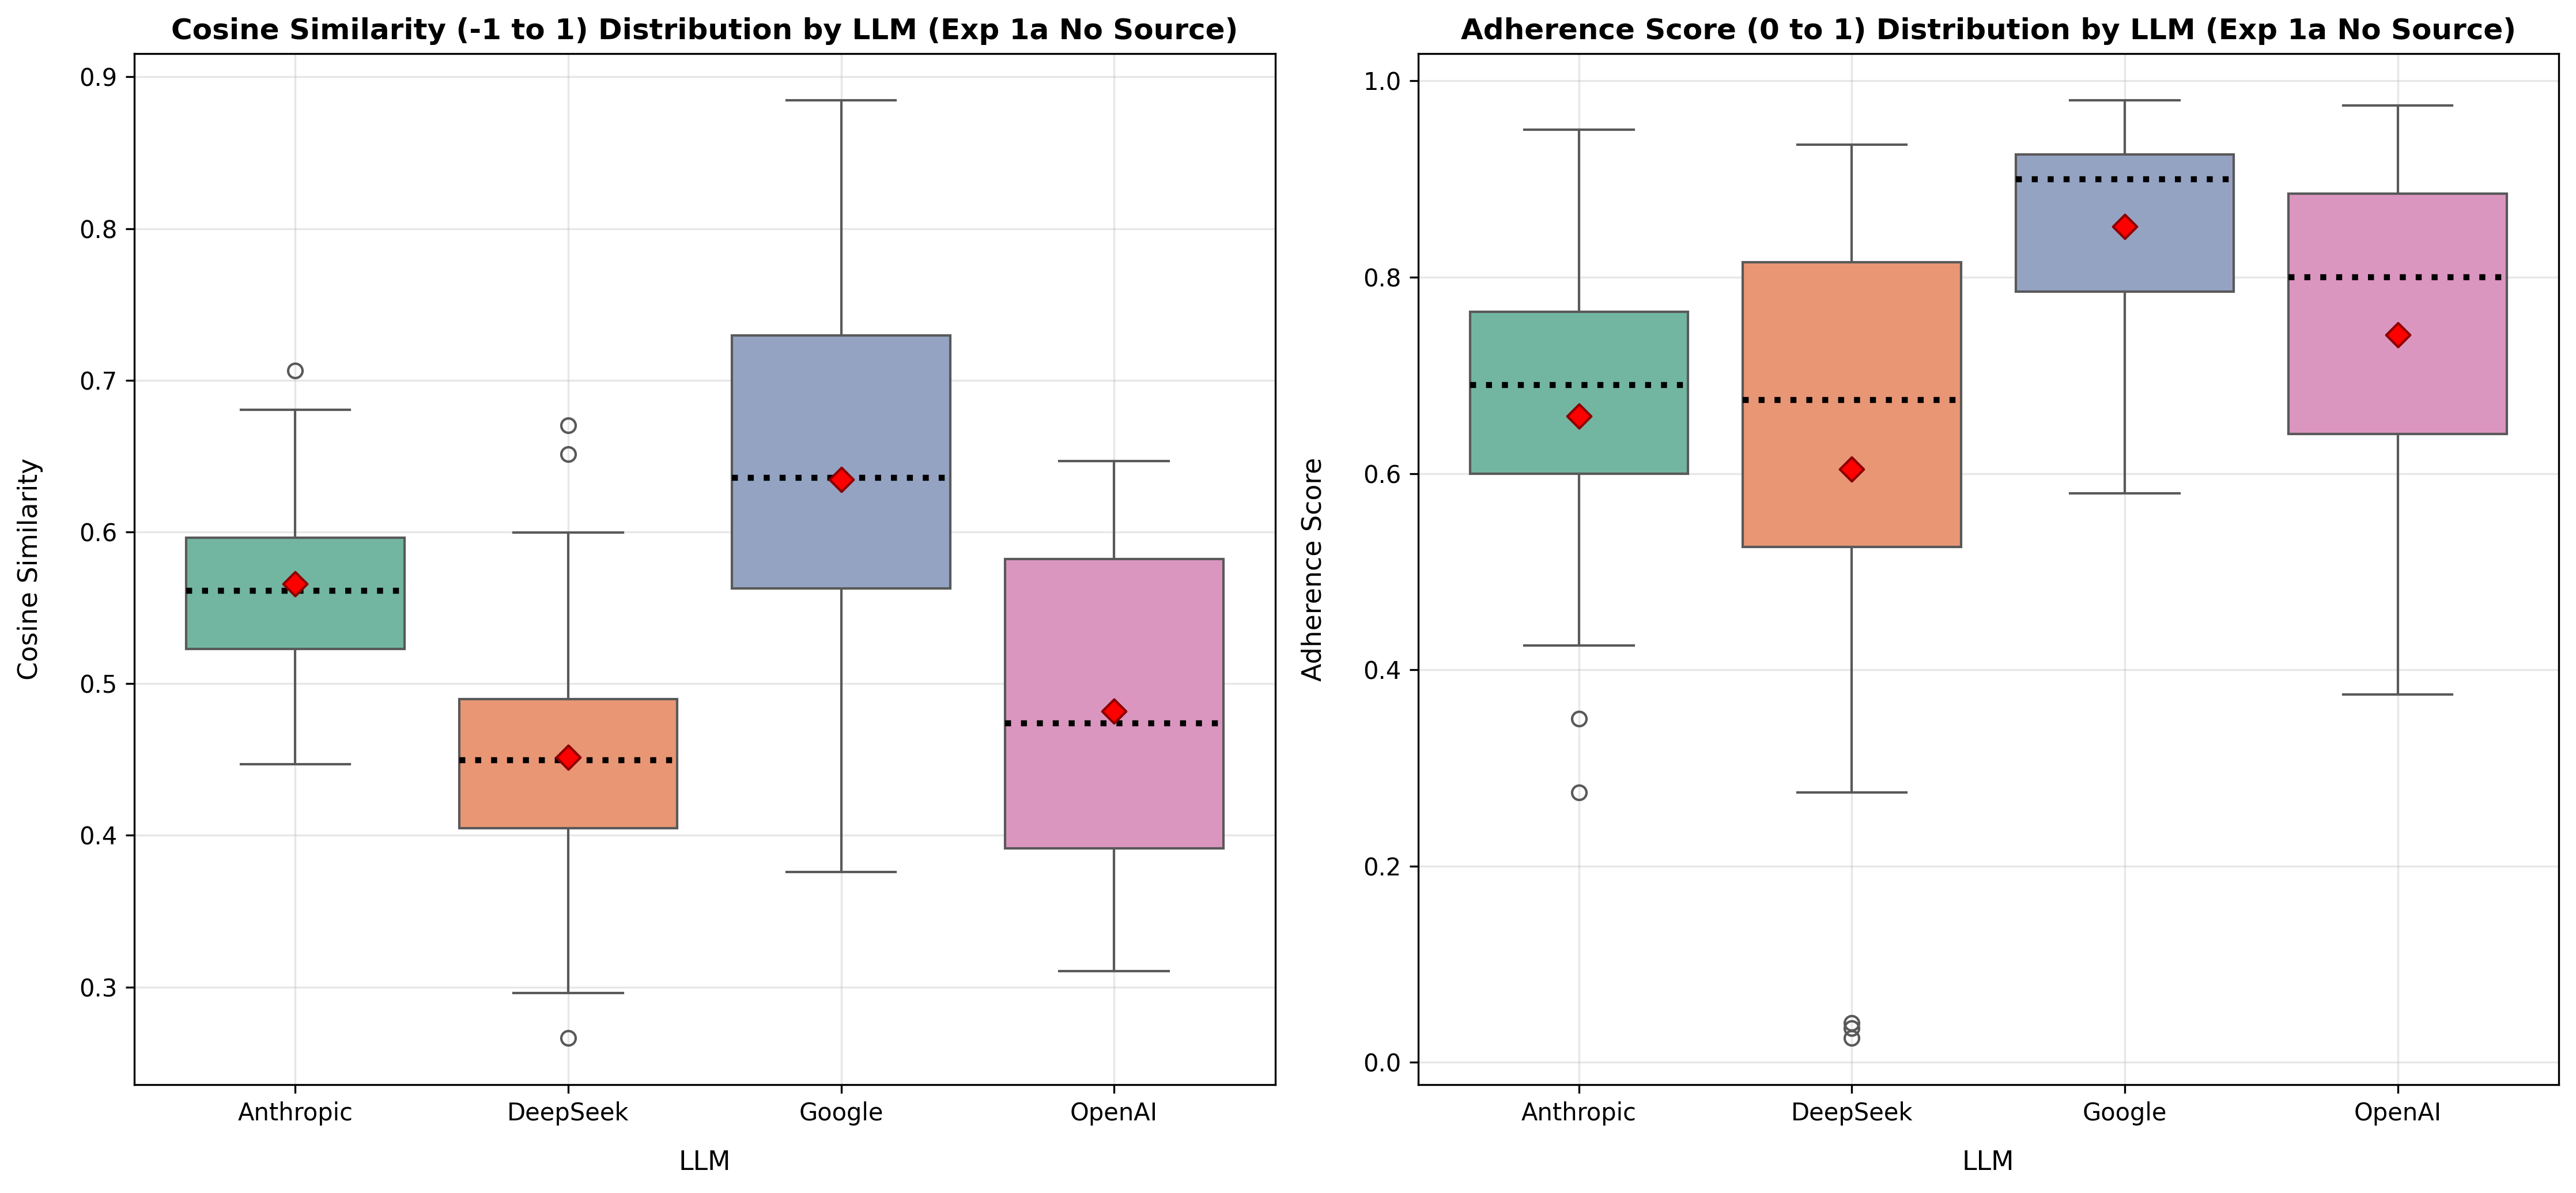

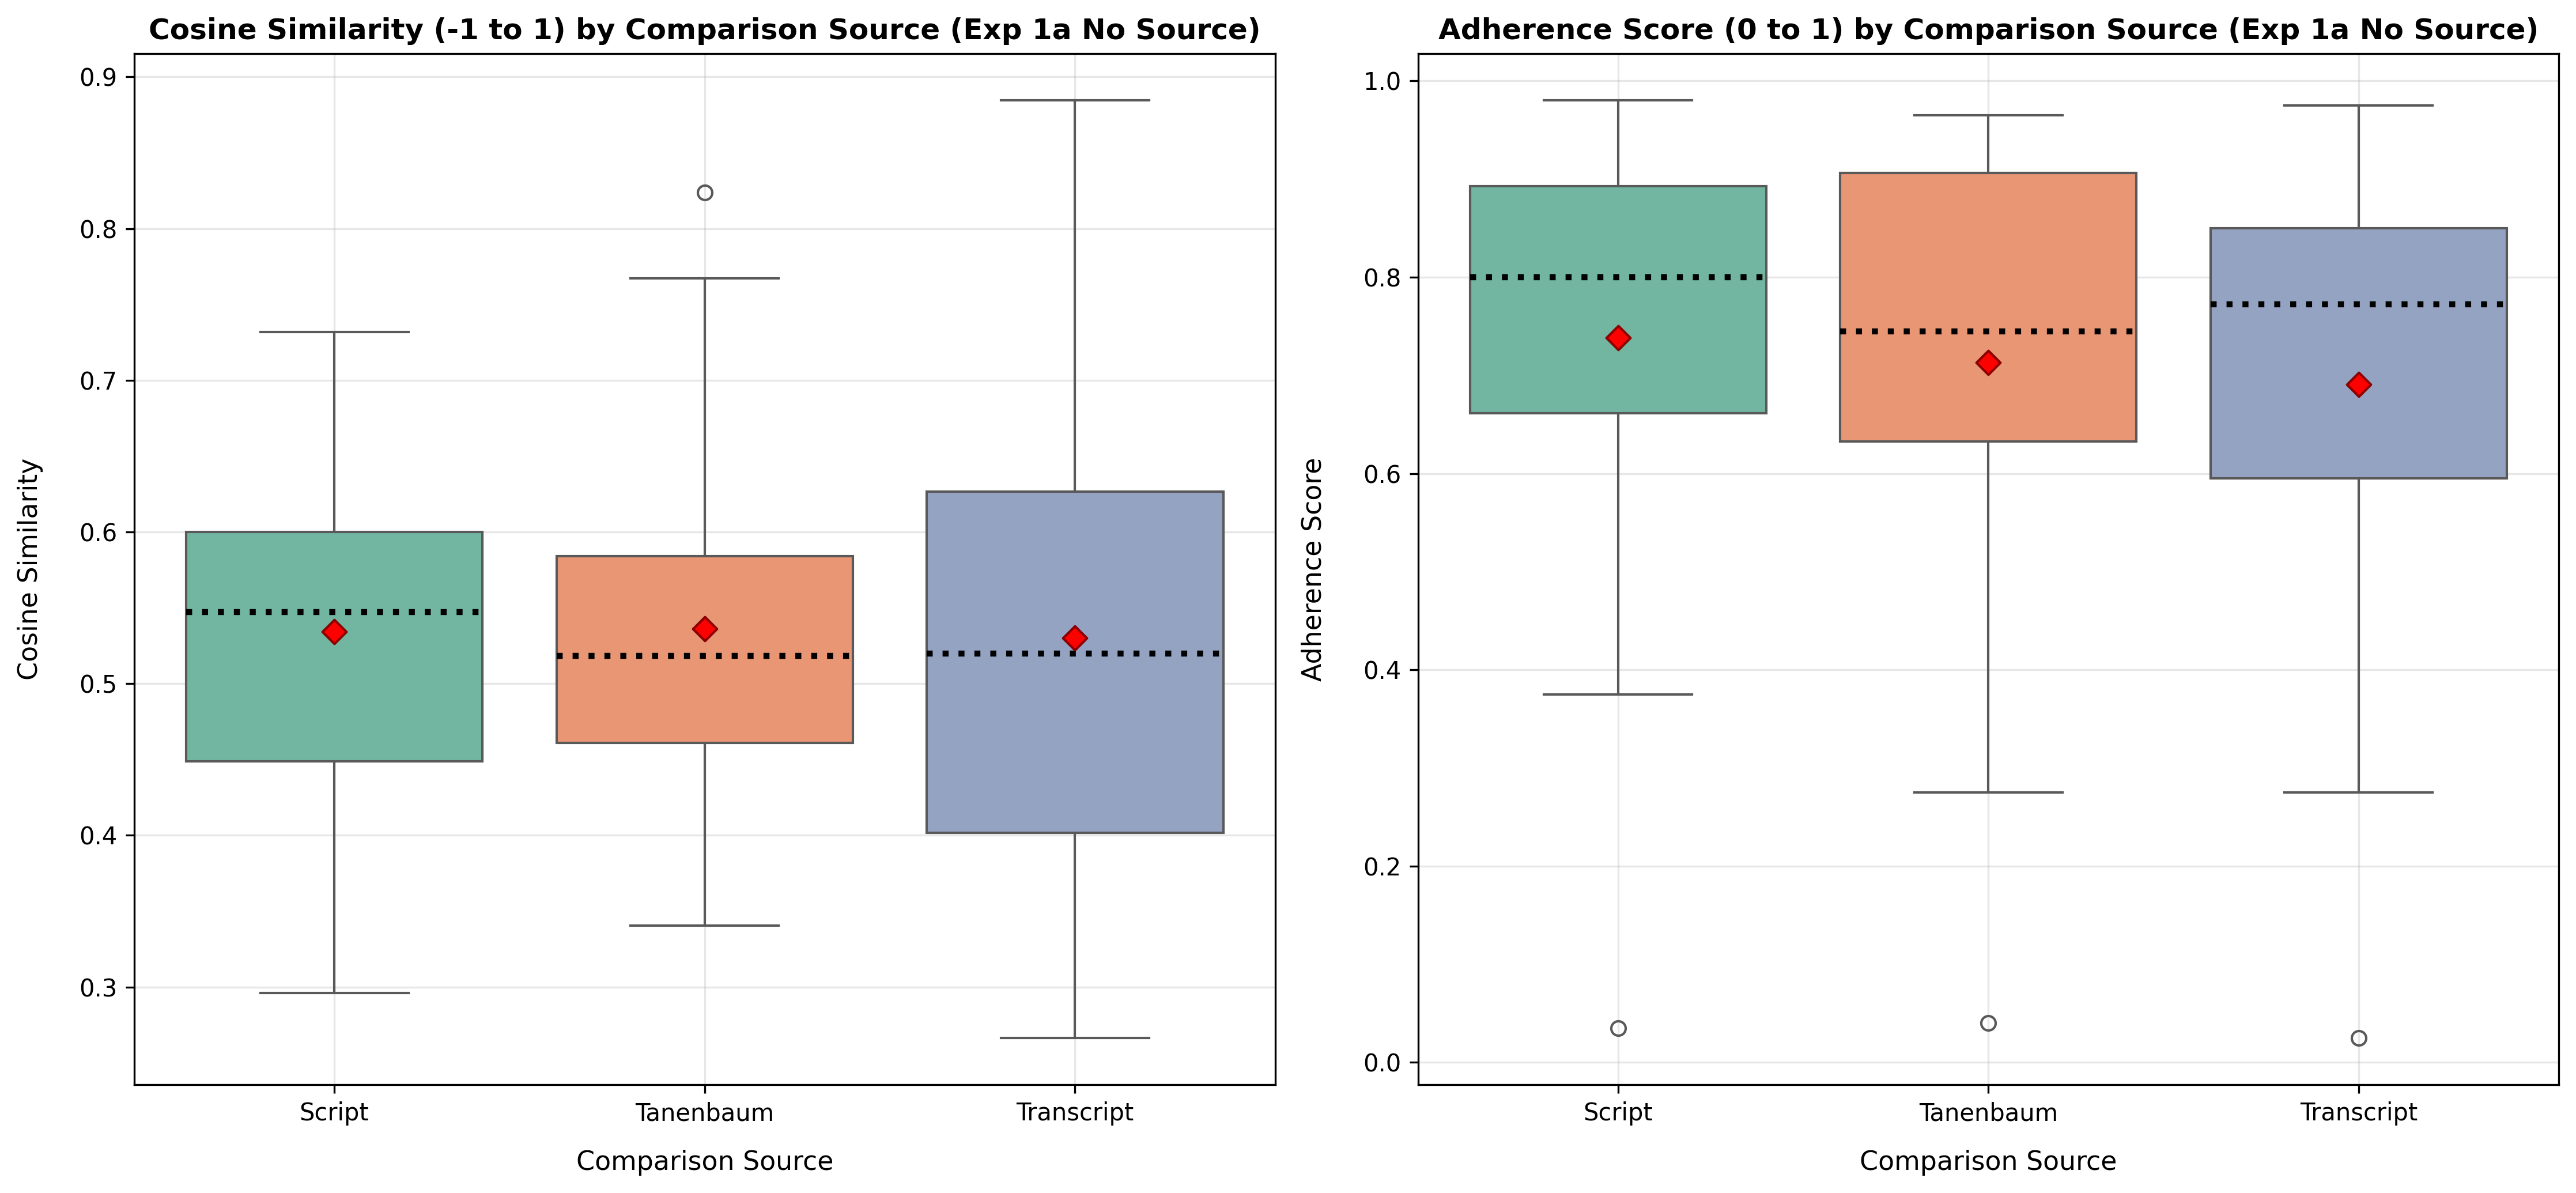

exp1a_no_source plots created successfully!


In [726]:
## Experiment 1a No Source

if exp1a_no_source_df is not None:
    print("Creating plots for exp1a_no_source data...")
    
    # Check if we have the new expanded structure
    has_comparison_source = 'comparison_source' in exp1a_no_source_df.columns
    
    if has_comparison_source:
        # New expanded structure: plot by comparison_source
        print(f"Data shape: {exp1a_no_source_df.shape}")
        print(f"Comparison sources: {exp1a_no_source_df['comparison_source'].unique()}")
        
        # Plot 1: Distribution by LLM (aggregated across all comparison sources)
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        plots['exp1a_no_source_dist_by_llm'] = fig

        create_seaborn_boxplot(exp1a_no_source_df, 'llm', 'cosine_similarity', ax[0], 
                              'Cosine Similarity (-1 to 1) Distribution by LLM (Exp 1a No Source)',
                              'Cosine Similarity', 'LLM')

        create_seaborn_boxplot(exp1a_no_source_df, 'llm', 'adherence_score', ax[1],
                              'Adherence Score (0 to 1) Distribution by LLM (Exp 1a No Source)', 
                              'Adherence Score', 'LLM')

        plt.tight_layout()
        plt.show()
        
        # Plot 2: Distribution by comparison source
        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        plots['exp1a_no_source_dist_by_comparison_source'] = fig

        create_seaborn_boxplot(exp1a_no_source_df, 'comparison_source', 'cosine_similarity', ax[0], 
                              'Cosine Similarity (-1 to 1) by Comparison Source (Exp 1a No Source)',
                              'Cosine Similarity', 'Comparison Source')

        create_seaborn_boxplot(exp1a_no_source_df, 'comparison_source', 'adherence_score', ax[1],
                              'Adherence Score (0 to 1) by Comparison Source (Exp 1a No Source)', 
                              'Adherence Score', 'Comparison Source')

        plt.tight_layout()
        plt.show()
        
    print("exp1a_no_source plots created successfully!")
else:
    print("Skipping exp1a_no_source plots - data not available.")

Creating combined Input Source vs No Source comparison plot...


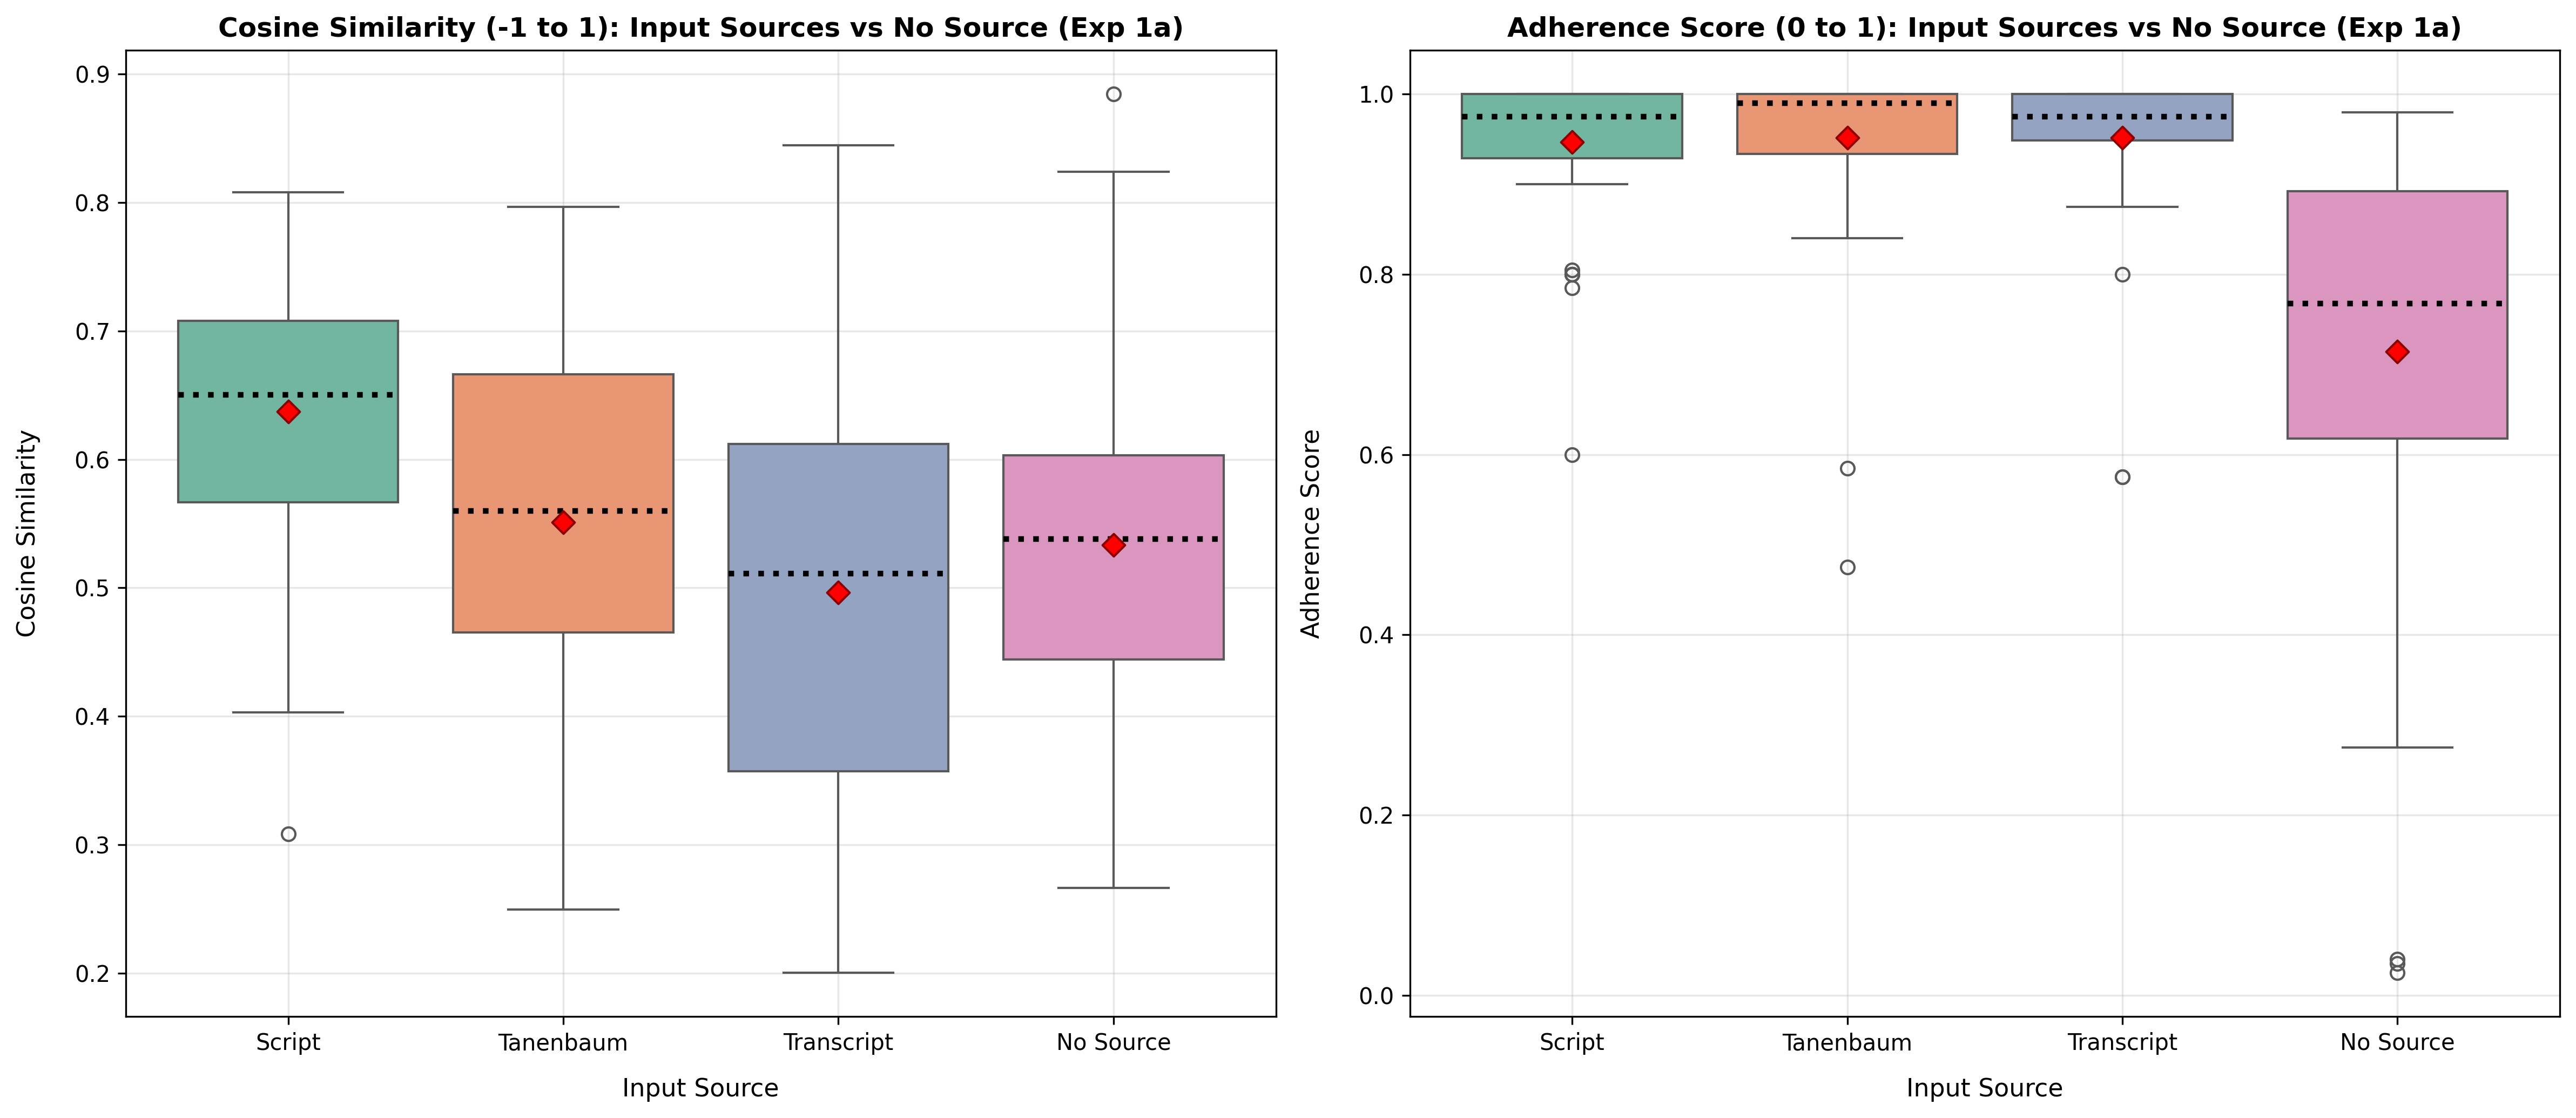


Summary Statistics:


cosine_similarity                 adherence_score                
                          mean       std count            mean       std count
input_source                                                                  
no_source             0.533408  0.125514    84        0.713988  0.218106    84
script                0.637166  0.107065    56        0.947054  0.075364    56
tanenbaum             0.551117  0.131404    56        0.951696  0.092713    56
transcript            0.496441  0.177308    56        0.951607  0.084521    56


Input Source vs No Source comparison created successfully!


In [727]:
# Combined Input Source vs No Source Comparison
if exp1a_no_source_df is not None:
    print("Creating combined Input Source vs No Source comparison plot...")
    
    # Prepare regular exp1a data
    exp1a_regular = exp1a_df.copy()
    
    exp1a_no_source_agg = exp1a_no_source_df.copy()
    exp1a_no_source_agg['input_source'] = 'no_source'
    
    comparison_df = pd.concat([exp1a_regular, exp1a_no_source_agg], ignore_index=True)
    
    # Create the comparison plot
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    plots['exp1a_input_source_vs_no_source_comparison'] = fig
    
    comparison_means = comparison_df.groupby('input_source')[['cosine_similarity', 'adherence_score']].mean()
    
    create_seaborn_boxplot(comparison_df, 'input_source', 'cosine_similarity', ax[0], 
                          'Cosine Similarity: Input Sources vs No Source (Exp 1a)', 
                          'Cosine Similarity', 'Input Source',
                          custom_means=comparison_means['cosine_similarity'])
    
    create_seaborn_boxplot(comparison_df, 'input_source', 'adherence_score', ax[1],
                          'Adherence Score: Input Sources vs No Source (Exp 1a)', 
                          'Adherence Score', 'Input Source',
                          custom_means=comparison_means['adherence_score'])
    
    plt.tight_layout()
    plt.show()
    
    comparison_summary = comparison_df.groupby('input_source')[['cosine_similarity', 'adherence_score']].agg(['mean', 'std', 'count'])
    tables['exp1a_input_source_vs_no_source_summary'] = comparison_summary
    
    print("\nSummary Statistics:")
    display(comparison_summary)
    
    print("\nInput Source vs No Source comparison created successfully!")
else:
    print("Skipping Input Source vs No Source comparison - exp1a_no_source data not available.")

## Save all tables and plots

In [728]:
def save_all_tables_and_plots():
    for name, df in tables.items():
        if name.startswith("exp1a_no_source"):
            output_dir = output_dir_exp1a_no_source
            table_name = name.replace("exp1a_no_source_", "")
        elif name.startswith("exp1a"):
            output_dir = output_dir_exp1a
            table_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_dir_exp1b
            table_name = name.replace("exp1b_", "")
        else:
            if "exp1" in name:
                base_filename = os.path.join(output_dir_exp1a, name)
                csv_path = f"{base_filename}.csv"
                df.to_csv(csv_path)
                print(f"Saved {csv_path}")
            continue

        base_filename = os.path.join(output_dir, table_name)
        
        csv_path = f"{base_filename}.csv"
        df.to_csv(csv_path)
        print(f"Saved {csv_path}")

    for name, fig in plots.items():
        if name.startswith("exp1a_no_source") or "no_source" in name:
            output_dir = output_plot_dir_exp1a_no_source
            plot_name = name.replace("exp1a_no_source_", "").replace("exp1a_", "")
        elif name.startswith("exp1a"):
            output_dir = output_plot_dir_exp1a
            plot_name = name.replace("exp1a_", "")
        elif name.startswith("exp1b"):
            output_dir = output_plot_dir_exp1b
            plot_name = name.replace("exp1b_", "")
        else:
            if "exp1" in name:
                base_filename = os.path.join(output_plot_dir_exp1a, name)
                png_path = f"{base_filename}.png"
                fig.savefig(png_path, bbox_inches='tight')
                print(f"Saved {png_path}")
            continue
        
        base_filename = os.path.join(output_dir, plot_name)
        
        png_path = f"{base_filename}.png"
        fig.savefig(png_path, bbox_inches='tight')
        print(f"Saved {png_path}")

save_all_tables_and_plots()

Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_llm.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/metrics_by_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/cosine_sim_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_prompt_type.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1a/adherence_llm_vs_input_source.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1b/metrics_by_llm.csv
Saved /home/malde/git/bachelor-thesis/40_evaluation/exp1/quantitative/tables/exp1b/cosine_sim_llm_vs_prompt